<h2><b> TRAIN-TEST SPLIT

In [2]:
# ==========================================
# RADAR PROJECT — MODELING NOTEBOOK
# Load dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [3]:
df = pd.read_csv("radar_modeling_ready.csv")

print(f"✅ Dataset loaded: {df.shape}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())
print(f"\nSample:")
print(df.head(3))

✅ Dataset loaded: (4844, 2)

Category distribution:
category
cs.CE      449
cs.AI      447
math.AC    446
cs.DS      444
math.GR    443
cs.CV      442
cs.NE      442
cs.SY      441
math.ST    440
cs.IT      433
cs.PL      417
Name: count, dtype: int64

Sample:
                                      clean_abstract category
0  autonomous system substantially enhance human ...    cs.AI
1  paper develop novel paradigm namely hypergraph...    cs.AI
2  introduce framework leverage knowledge acquire...    cs.AI


In [4]:
# ==========================================
# Train / Test Split (stratified)
# ==========================================

from sklearn.model_selection import train_test_split

X = df['clean_abstract']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # ensures each category is proportionally represented in both splits
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"\nTrain category distribution:")
print(y_train.value_counts())
print(f"\nTest category distribution:")
print(y_test.value_counts())

Train size: 3875
Test size:  969

Train category distribution:
category
cs.CE      359
math.AC    357
cs.AI      357
cs.DS      355
math.GR    354
cs.NE      354
cs.CV      354
cs.SY      353
math.ST    352
cs.IT      346
cs.PL      334
Name: count, dtype: int64

Test category distribution:
category
cs.AI      90
cs.CE      90
math.GR    89
cs.DS      89
math.AC    89
cs.NE      88
cs.SY      88
math.ST    88
cs.CV      88
cs.IT      87
cs.PL      83
Name: count, dtype: int64


In [5]:
# ==========================================
# Feature Extraction — TF-IDF Unigram
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Fit ONLY on training data, then transform both
tfidf_unigram = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words='english',
    sublinear_tf=True     # applies log normalization to term frequency — helps with imbalanced term counts
)

X_train_tfidf = tfidf_unigram.fit_transform(X_train)
X_test_tfidf  = tfidf_unigram.transform(X_test)   # transform only, never fit on test

print(f"TF-IDF Unigram feature matrix:")
print(f"Train: {X_train_tfidf.shape}")
print(f"Test:  {X_test_tfidf.shape}")

TF-IDF Unigram feature matrix:
Train: (3875, 5000)
Test:  (969, 5000)


DONOT RUN AGAIN

In [6]:
# # ==========================================
# # Feature Extraction — TF-IDF Bigram
# # ==========================================

# tfidf_bigram = TfidfVectorizer(
#     max_features=5000,
#     ngram_range=(1, 2),   # unigrams + bigrams combined
#     stop_words='english',
#     sublinear_tf=True
# )

# X_train_bigram = tfidf_bigram.fit_transform(X_train)
# X_test_bigram  = tfidf_bigram.transform(X_test)

# print(f"TF-IDF Bigram feature matrix:")
# print(f"Train: {X_train_bigram.shape}")
# print(f"Test:  {X_test_bigram.shape}")

DONOT RUN AGAIN

In [7]:
# # ==========================================
# # Feature Extraction — Sentence-BERT
# # ==========================================

# !pip install sentence-transformers -q

# from sentence_transformers import SentenceTransformer

# model_sbert = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight, fast, strong performance

# print("⚙️ Encoding training abstracts...")
# X_train_sbert = model_sbert.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)

# print("⚙️ Encoding test abstracts...")
# X_test_sbert  = model_sbert.encode(X_test.tolist(),  batch_size=64, show_progress_bar=True)

# print(f"\nSBERT embedding shape:")
# print(f"Train: {X_train_sbert.shape}")
# print(f"Test:  {X_test_sbert.shape}")

DONOT RUN AGAIN

In [8]:
# # Save feature matrices to disk so you never have to rerun them
# import numpy as np
# from scipy import sparse

# # TF-IDF matrices (sparse)
# sparse.save_npz("X_train_tfidf.npz", X_train_tfidf)
# sparse.save_npz("X_test_tfidf.npz",  X_test_tfidf)
# sparse.save_npz("X_train_bigram.npz", X_train_bigram)
# sparse.save_npz("X_test_bigram.npz",  X_test_bigram)

# # SBERT matrices (dense numpy arrays)
# np.save("X_train_sbert.npy", X_train_sbert)
# np.save("X_test_sbert.npy",  X_test_sbert)

# # Save labels
# y_train.to_csv("y_train.csv", index=False)
# y_test.to_csv("y_test.csv",   index=False)

# print("✅ All feature matrices saved to disk.")

WHENEVER I START COLAB FILE AGAIN JUST LOAD THESE DONOT RUN THE ABOVE CELLS AGAIN


In [9]:
# from scipy import sparse
# import numpy as np
# import pandas as pd

# X_train_tfidf  = sparse.load_npz("X_train_tfidf.npz")
# X_test_tfidf   = sparse.load_npz("X_test_tfidf.npz")
# X_train_bigram = sparse.load_npz("X_train_bigram.npz")
# X_test_bigram  = sparse.load_npz("X_test_bigram.npz")
# X_train_sbert  = np.load("X_train_sbert.npy")
# X_test_sbert   = np.load("X_test_sbert.npy")
# y_train        = pd.read_csv("y_train.csv").squeeze()
# y_test         = pd.read_csv("y_test.csv").squeeze()

# print("✅ All matrices reloaded successfully.")

<H3><B>LABEL ENCODING

cs.AI   → 0<br>
cs.CE   → 1<br>
cs.CV   → 2<br>
cs.DS   → 3<br>
cs.IT   → 4<br>
cs.NE   → 5<br>
cs.PL   → 6<br>
cs.SY   → 7<br>
math.AC → 8<br>
math.GR → 9<br>
math.ST → 10

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)
print("Encoded train sample:", y_train_enc[:5])
print("Original labels back:", le.inverse_transform(y_train_enc[:5]))

Classes: ['cs.AI' 'cs.CE' 'cs.CV' 'cs.DS' 'cs.IT' 'cs.NE' 'cs.PL' 'cs.SY' 'math.AC'
 'math.GR' 'math.ST']
Encoded train sample: [10  0 10  9  9]
Original labels back: ['math.ST' 'cs.AI' 'math.ST' 'math.GR' 'math.GR']


<H3><B>STANDARD SCALING FOR SBERT

In [11]:
# # ==========================================
# # Scale SBERT Embeddings
# # ==========================================

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_sbert_scaled = scaler.fit_transform(X_train_sbert)  # fit only on train
# X_test_sbert_scaled  = scaler.transform(X_test_sbert)       # transform only on test

# print(f"Scaled SBERT train shape: {X_train_sbert_scaled.shape}")
# print(f"Scaled SBERT test shape:  {X_test_sbert_scaled.shape}")
# print(f"\nMean (should be ~0): {X_train_sbert_scaled.mean():.6f}")
# print(f"Std  (should be ~1): {X_train_sbert_scaled.std():.6f}")

<H2><B> MODELING

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
import time
import warnings
warnings.filterwarnings('ignore')

<H2><B> MODELING: TF-IDF UNIGRAMS

In [13]:
# # ==========================================
# # MODELING — All Models on TF-IDF Unigram
# # ==========================================

# # ---- Define all models ----
# models_tfidf = {
#     'Logistic Regression': LogisticRegression(
#         max_iter=1000,
#         C=1.0,
#         solver='lbfgs',
#         multi_class='multinomial',
#         random_state=42
#     ),
#     'Linear SVM': CalibratedClassifierCV(  # wrapped for predict_proba support
#         LinearSVC(max_iter=2000, C=1.0, random_state=42)
#     ),
#     'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     ),
# }

# # ---- Train and evaluate each model ----
# tfidf_results = {}

# for name, model in models_tfidf.items():
#     print(f"\n⚙️  Training: {name}")
#     start = time.time()

#     model.fit(X_train_tfidf, y_train_enc)
#     train_time = time.time() - start

#     y_pred = model.predict(X_test_tfidf)

#     acc = accuracy_score(y_test_enc, y_pred)
#     f1  = f1_score(y_test_enc, y_pred, average='macro')

#     tfidf_results[name] = {
#         'accuracy': round(acc, 4),
#         'macro_f1': round(f1, 4),
#         'train_time_sec': round(train_time, 2),
#         'model': model
#     }

#     print(f"   Accuracy:  {acc:.4f}")
#     print(f"   Macro F1:  {f1:.4f}")
#     print(f"   Time:      {train_time:.2f}s")

# print("\n✅ TF-IDF Unigram modeling complete.")

In [14]:
# # ==========================================
# # Detailed Report for Best TF-IDF Model
# # ==========================================

# # Find best model by macro F1
# best_name = max(tfidf_results, key=lambda x: tfidf_results[x]['macro_f1'])
# best_model = tfidf_results[best_name]['model']

# print(f"Best model on TF-IDF Unigram: {best_name}")
# print(f"Macro F1: {tfidf_results[best_name]['macro_f1']}")
# print(f"\nDetailed Classification Report:")
# print(classification_report(
#     y_test_enc,
#     best_model.predict(X_test_tfidf),
#     target_names=le.classes_
# ))

In [15]:
# # ==========================================
# # Confusion Matrix for Best TF-IDF Model
# # ==========================================

# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# y_pred_best = best_model.predict(X_test_tfidf)
# cm = confusion_matrix(y_test_enc, y_pred_best)

# plt.figure(figsize=(12, 9))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=le.classes_,
#     yticklabels=le.classes_,
#     linewidths=0.5
# )
# plt.title(f'Confusion Matrix — {best_name} (TF-IDF Unigram)',
#           fontsize=13, fontweight='bold')
# plt.ylabel('True Label', fontsize=11)
# plt.xlabel('Predicted Label', fontsize=11)
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.savefig('confusion_matrix_tfidf_unigram.png', dpi=150)
# plt.show()

<H2><B> MODELING: TF-IDF BIGRAMS

In [16]:
# # ==========================================
# # MODELING — All Models on TF-IDF Bigram
# # ==========================================

# models_bigram = {
#     'Logistic Regression': LogisticRegression(
#         max_iter=1000, C=1.0, solver='lbfgs',
#         multi_class='multinomial', random_state=42
#     ),
#     'Linear SVM': CalibratedClassifierCV(
#         LinearSVC(max_iter=2000, C=1.0, random_state=42)
#     ),
#     'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=200, random_state=42, n_jobs=-1
#     ),
# }

# bigram_results = {}

# for name, model in models_bigram.items():
#     print(f"\n⚙️  Training: {name}")
#     start = time.time()

#     model.fit(X_train_bigram, y_train_enc)
#     train_time = time.time() - start

#     y_pred = model.predict(X_test_bigram)
#     acc = accuracy_score(y_test_enc, y_pred)
#     f1  = f1_score(y_test_enc, y_pred, average='macro')

#     bigram_results[name] = {
#         'accuracy': round(acc, 4),
#         'macro_f1': round(f1, 4),
#         'train_time_sec': round(train_time, 2),
#         'model': model
#     }

#     print(f"   Accuracy:  {acc:.4f}")
#     print(f"   Macro F1:  {f1:.4f}")
#     print(f"   Time:      {train_time:.2f}s")

# # Best bigram model report
# best_bigram_name = max(bigram_results, key=lambda x: bigram_results[x]['macro_f1'])
# best_bigram_model = bigram_results[best_bigram_name]['model']

# print(f"\n✅ TF-IDF Bigram complete.")
# print(f"Best: {best_bigram_name} — Macro F1: {bigram_results[best_bigram_name]['macro_f1']}")
# print(f"\nDetailed Classification Report:")
# print(classification_report(
#     y_test_enc,
#     best_bigram_model.predict(X_test_bigram),
#     target_names=le.classes_
# ))

<H2><B> MODELING: SBERT

In [17]:
# # ==========================================
# # Cell 11: MODELING — All Models on SBERT Embeddings
# # ==========================================

# from xgboost import XGBClassifier
# from sklearn.neighbors import KNeighborsClassifier

# models_sbert = {
#     'Logistic Regression': LogisticRegression(
#         max_iter=1000, C=1.0, solver='lbfgs',
#         multi_class='multinomial', random_state=42
#     ),
#     'Linear SVM': CalibratedClassifierCV(
#         LinearSVC(max_iter=2000, C=1.0, random_state=42)
#     ),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=200, random_state=42, n_jobs=-1
#     ),
#     'XGBoost': XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         use_label_encoder=False,
#         eval_metric='mlogloss',
#         random_state=42,
#         n_jobs=-1
#     ),
#     'KNN': KNeighborsClassifier(
#         n_neighbors=7,
#         metric='cosine',    # cosine distance is most meaningful for SBERT embeddings
#         n_jobs=-1
#     ),
# }

# sbert_results = {}

# for name, model in models_sbert.items():
#     print(f"\n⚙️  Training: {name}")
#     start = time.time()

#     model.fit(X_train_sbert_scaled, y_train_enc)
#     train_time = time.time() - start

#     y_pred = model.predict(X_test_sbert_scaled)
#     acc = accuracy_score(y_test_enc, y_pred)
#     f1  = f1_score(y_test_enc, y_pred, average='macro')

#     sbert_results[name] = {
#         'accuracy': round(acc, 4),
#         'macro_f1': round(f1, 4),
#         'train_time_sec': round(train_time, 2),
#         'model': model
#     }

#     print(f"   Accuracy:  {acc:.4f}")
#     print(f"   Macro F1:  {f1:.4f}")
#     print(f"   Time:      {train_time:.2f}s")

# # Best SBERT model
# best_sbert_name = max(sbert_results, key=lambda x: sbert_results[x]['macro_f1'])
# best_sbert_model = sbert_results[best_sbert_name]['model']

# print(f"\n✅ SBERT modeling complete.")
# print(f"Best: {best_sbert_name} — Macro F1: {sbert_results[best_sbert_name]['macro_f1']}")
# print(f"\nDetailed Classification Report:")
# print(classification_report(
#     y_test_enc,
#     best_sbert_model.predict(X_test_sbert_scaled),
#     target_names=le.classes_
# ))

In [18]:
# import torch
# print("GPU available:", torch.cuda.is_available())
# print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

<H2><B>IMPROVING ACCURACY

In [19]:
# # ==========================================
# # PATH 2: Larger TF-IDF Vocabulary (15k features)
# # ==========================================

# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import f1_score, accuracy_score, classification_report

# tfidf_large = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1, 1),
#     stop_words='english',
#     sublinear_tf=True,
#     min_df=2,
#     max_df=0.95
# )

# X_train_large = tfidf_large.fit_transform(X_train)
# X_test_large  = tfidf_large.transform(X_test)

# lr_large = LogisticRegression(
#     max_iter=1000, C=1.0,
#     solver='lbfgs',
#     multi_class='multinomial',
#     random_state=42
# )
# lr_large.fit(X_train_large, y_train_enc)
# y_pred_large = lr_large.predict(X_test_large)

# acc = accuracy_score(y_test_enc, y_pred_large)
# f1  = f1_score(y_test_enc, y_pred_large, average='macro')
# print(f"Path 2 — Large TF-IDF (15k): Accuracy={acc:.4f}, Macro F1={f1:.4f}")

In [20]:
# # ==========================================
# # PATH 1: Hyperparameter Tuning on Large TF-IDF
# # ==========================================

# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'C': [0.1, 1, 5, 10, 50],
#     'solver': ['lbfgs', 'saga']
# }

# grid = GridSearchCV(
#     LogisticRegression(
#         multi_class='multinomial',
#         random_state=42,
#         max_iter=2000
#     ),
#     param_grid,
#     cv=5,
#     scoring='f1_macro',
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_large, y_train_enc)

# print(f"\nBest params: {grid.best_params_}")
# print(f"Best CV Macro F1: {grid.best_score_:.4f}")

# # Evaluate on test set
# y_pred_tuned = grid.best_estimator_.predict(X_test_large)
# acc = accuracy_score(y_test_enc, y_pred_tuned)
# f1  = f1_score(y_test_enc, y_pred_tuned, average='macro')
# print(f"\nPath 1+2 — Tuned LR + Large TF-IDF: Accuracy={acc:.4f}, Macro F1={f1:.4f}")
# print(classification_report(y_test_enc, y_pred_tuned, target_names=le.classes_))

In [21]:
# # ==========================================
# # PATH 3: Hybrid TF-IDF + SBERT Features
# # ==========================================

# from scipy.sparse import hstack, csr_matrix

# X_train_hybrid = hstack([X_train_large, csr_matrix(X_train_sbert_scaled)])
# X_test_hybrid  = hstack([X_test_large,  csr_matrix(X_test_sbert_scaled)])

# print(f"Hybrid feature shape: {X_train_hybrid.shape}")

# lr_hybrid = LogisticRegression(
#     C=grid.best_params_['C'],
#     solver='lbfgs',
#     multi_class='multinomial',
#     max_iter=2000,
#     random_state=42
# )
# lr_hybrid.fit(X_train_hybrid, y_train_enc)
# y_pred_hybrid = lr_hybrid.predict(X_test_hybrid)

# acc = accuracy_score(y_test_enc, y_pred_hybrid)
# f1  = f1_score(y_test_enc, y_pred_hybrid, average='macro')
# print(f"\nPath 3 — Hybrid TF-IDF+SBERT: Accuracy={acc:.4f}, Macro F1={f1:.4f}")
# print(classification_report(y_test_enc, y_pred_hybrid, target_names=le.classes_))

In [22]:
# # ==========================================
# # PATH 4: SciBERT Embeddings (GPU accelerated)
# # ==========================================

# !pip install transformers -q

# from transformers import AutoTokenizer, AutoModel
# import torch
# import numpy as np

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# tokenizer = AutoTokenizer.from_pretrained('allenai/scibert_scivocab_uncased')
# scibert   = AutoModel.from_pretrained('allenai/scibert_scivocab_uncased').to(device)
# scibert.eval()

# def get_scibert_embeddings(texts, batch_size=64):
#     all_embeddings = []
#     texts = list(texts)
#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i+batch_size]
#         encoded = tokenizer(
#             batch,
#             padding=True,
#             truncation=True,
#             max_length=256,
#             return_tensors='pt'
#         ).to(device)
#         with torch.no_grad():
#             output = scibert(**encoded)
#         embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
#         all_embeddings.append(embeddings)
#         if i % 500 == 0:
#             print(f"  Encoded {i}/{len(texts)}...")
#     return np.vstack(all_embeddings)

# print("⚙️ Encoding training set with SciBERT...")
# X_train_scibert = get_scibert_embeddings(X_train.tolist())
# print("⚙️ Encoding test set with SciBERT...")
# X_test_scibert  = get_scibert_embeddings(X_test.tolist())
# print(f"✅ SciBERT embeddings shape: {X_train_scibert.shape}")

In [23]:
# # ==========================================
# # PATH 4 continued: Train models on SciBERT
# # ==========================================

# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV
# from scipy.sparse import hstack, csr_matrix

# # Scale SciBERT embeddings
# scaler_sci = StandardScaler()
# X_train_scibert_scaled = scaler_sci.fit_transform(X_train_scibert)
# X_test_scibert_scaled  = scaler_sci.transform(X_test_scibert)

# print("--- SciBERT + Logistic Regression ---")
# lr_sci = LogisticRegression(
#     C=5, max_iter=2000,
#     multi_class='multinomial', random_state=42
# )
# lr_sci.fit(X_train_scibert_scaled, y_train_enc)
# y_pred_sci_lr = lr_sci.predict(X_test_scibert_scaled)
# acc = accuracy_score(y_test_enc, y_pred_sci_lr)
# f1  = f1_score(y_test_enc, y_pred_sci_lr, average='macro')
# print(f"Accuracy={acc:.4f}, Macro F1={f1:.4f}")
# print(classification_report(y_test_enc, y_pred_sci_lr, target_names=le.classes_))

# print("\n--- SciBERT + Linear SVM ---")
# svm_sci = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
# svm_sci.fit(X_train_scibert_scaled, y_train_enc)
# y_pred_sci_svm = svm_sci.predict(X_test_scibert_scaled)
# acc = accuracy_score(y_test_enc, y_pred_sci_svm)
# f1  = f1_score(y_test_enc, y_pred_sci_svm, average='macro')
# print(f"Accuracy={acc:.4f}, Macro F1={f1:.4f}")
# print(classification_report(y_test_enc, y_pred_sci_svm, target_names=le.classes_))

# print("\n--- SciBERT + TF-IDF 5k Hybrid ---")
# X_train_sci_hybrid = hstack([X_train_tfidf, csr_matrix(X_train_scibert_scaled)])
# X_test_sci_hybrid  = hstack([X_test_tfidf,  csr_matrix(X_test_scibert_scaled)])
# print(f"Hybrid shape: {X_train_sci_hybrid.shape}")

# lr_sci_hybrid = LogisticRegression(
#     C=5, max_iter=2000,
#     multi_class='multinomial', random_state=42
# )
# lr_sci_hybrid.fit(X_train_sci_hybrid, y_train_enc)
# y_pred_sci_hybrid = lr_sci_hybrid.predict(X_test_sci_hybrid)
# acc = accuracy_score(y_test_enc, y_pred_sci_hybrid)
# f1  = f1_score(y_test_enc, y_pred_sci_hybrid, average='macro')
# print(f"Accuracy={acc:.4f}, Macro F1={f1:.4f}")
# print(classification_report(y_test_enc, y_pred_sci_hybrid, target_names=le.classes_))

In [24]:
# # ==========================================
# # FINE-TUNED SciBERT CLASSIFIER
# # ==========================================

# !pip install transformers datasets -q

# import torch
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
# from transformers import AutoTokenizer, AutoModel
# from sklearn.metrics import f1_score, accuracy_score, classification_report
# import numpy as np

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using: {device}")

# # ---- Dataset class ----
# class AbstractDataset(Dataset):
#     def __init__(self, texts, labels, tokenizer, max_len=256):
#         self.texts    = list(texts)
#         self.labels   = list(labels)
#         self.tokenizer = tokenizer
#         self.max_len  = max_len

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         enc = self.tokenizer(
#             self.texts[idx],
#             padding='max_length',
#             truncation=True,
#             max_length=self.max_len,
#             return_tensors='pt'
#         )
#         return {
#             'input_ids':      enc['input_ids'].squeeze(),
#             'attention_mask': enc['attention_mask'].squeeze(),
#             'label':          torch.tensor(self.labels[idx], dtype=torch.long)
#         }

# # ---- Model class ----
# class SciBERTClassifier(nn.Module):
#     def __init__(self, n_classes):
#         super().__init__()
#         self.bert    = AutoModel.from_pretrained('allenai/scibert_scivocab_uncased')
#         self.dropout = nn.Dropout(0.3)
#         self.fc      = nn.Linear(768, n_classes)

#     def forward(self, input_ids, attention_mask):
#         output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
#         cls_output = output.last_hidden_state[:, 0, :]
#         return self.fc(self.dropout(cls_output))

# # ---- Setup ----
# tokenizer  = AutoTokenizer.from_pretrained('allenai/scibert_scivocab_uncased')
# n_classes  = len(le.classes_)
# model_bert = SciBERTClassifier(n_classes).to(device)

# train_dataset = AbstractDataset(X_train.tolist(), y_train_enc, tokenizer)
# test_dataset  = AbstractDataset(X_test.tolist(),  y_test_enc,  tokenizer)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
# criterion = nn.CrossEntropyLoss()

# # ---- Training loop ----
# EPOCHS = 4

# for epoch in range(EPOCHS):
#     model_bert.train()
#     total_loss, correct, total = 0, 0, 0

#     for batch in train_loader:
#         input_ids      = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels         = batch['label'].to(device)

#         optimizer.zero_grad()
#         outputs = model_bert(input_ids, attention_mask)
#         loss    = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         preds       = outputs.argmax(dim=1)
#         correct    += (preds == labels).sum().item()
#         total      += labels.size(0)

#     train_acc = correct / total
#     print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss/len(train_loader):.4f}, Train Acc: {train_acc:.4f}")

# # ---- Evaluation ----
# model_bert.eval()
# all_preds, all_labels = [], []

# with torch.no_grad():
#     for batch in test_loader:
#         input_ids      = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels         = batch['label'].to(device)

#         outputs = model_bert(input_ids, attention_mask)
#         preds   = outputs.argmax(dim=1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# acc = accuracy_score(all_labels, all_preds)
# f1  = f1_score(all_labels, all_preds, average='macro')
# print(f"\n✅ Fine-tuned SciBERT — Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
# print(classification_report(all_labels, all_preds, target_names=le.classes_))

In [25]:
# # ==========================================
# # CONTINUE TRAINING — 4 more epochs
# # with learning rate scheduler
# # ==========================================

# from transformers import get_linear_schedule_with_warmup

# EXTRA_EPOCHS = 4
# total_steps  = len(train_loader) * EXTRA_EPOCHS

# scheduler = get_linear_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps   = total_steps // 10,
#     num_training_steps = total_steps
# )

# for epoch in range(EXTRA_EPOCHS):
#     model_bert.train()
#     total_loss, correct, total = 0, 0, 0

#     for batch in train_loader:
#         input_ids      = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels         = batch['label'].to(device)

#         optimizer.zero_grad()
#         outputs = model_bert(input_ids, attention_mask)
#         loss    = criterion(outputs, labels)
#         loss.backward()

#         # Gradient clipping — prevents exploding gradients
#         torch.nn.utils.clip_grad_norm_(model_bert.parameters(), max_norm=1.0)

#         optimizer.step()
#         scheduler.step()

#         total_loss += loss.item()
#         preds       = outputs.argmax(dim=1)
#         correct    += (preds == labels).sum().item()
#         total      += labels.size(0)

#     train_acc = correct / total

#     # Evaluate on test after every epoch
#     model_bert.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for batch in test_loader:
#             input_ids      = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             labels_b       = batch['label'].to(device)
#             outputs        = model_bert(input_ids, attention_mask)
#             preds          = outputs.argmax(dim=1)
#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels_b.cpu().numpy())

#     test_f1  = f1_score(all_labels, all_preds, average='macro')
#     test_acc = accuracy_score(all_labels, all_preds)

#     print(f"Epoch {epoch+5}/{EXTRA_EPOCHS+4} — "
#           f"Loss: {total_loss/len(train_loader):.4f}, "
#           f"Train Acc: {train_acc:.4f}, "
#           f"Test Acc: {test_acc:.4f}, "
#           f"Test F1: {test_f1:.4f}")

# # Final detailed report
# print(f"\n✅ Final Report:")
# print(classification_report(all_labels, all_preds, target_names=le.classes_))

In [26]:
# ==========================================
# REDUCED GRID SEARCH — Focused on what matters
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('lr',    LogisticRegression(multi_class='multinomial',
                                  random_state=42, max_iter=2000))
])

# Reduced grid — only most promising combos based on prior experiments
# C=1 was already good, 5k features already good, so focus around those
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range':  [(1,1)],       # bigram already proved worse, skip
    'tfidf__min_df':       [1, 2],
    'lr__C':               [1, 5, 10],
}

# 3 × 1 × 2 × 3 = 18 combinations × 5 folds = 90 fits — runs in 2-3 mins
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train_enc)

print(f"\n✅ Best params: {grid.best_params_}")
print(f"Best CV Macro F1: {grid.best_score_:.4f}")

y_pred_tuned = grid.best_estimator_.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred_tuned)
f1  = f1_score(y_test_enc, y_pred_tuned, average='macro')
print(f"\nTest Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_tuned, target_names=le.classes_))

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best params: {'lr__C': 5, 'tfidf__max_features': 20000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Best CV Macro F1: 0.7649

Test Accuracy: 0.7750
Test Macro F1: 0.7731
              precision    recall  f1-score   support

       cs.AI       0.56      0.46      0.50        90
       cs.CE       0.71      0.78      0.74        90
       cs.CV       0.79      0.78      0.79        88
       cs.DS       0.74      0.82      0.78        89
       cs.IT       0.81      0.75      0.78        87
       cs.NE       0.63      0.61      0.62        88
       cs.PL       0.83      0.87      0.85        83
       cs.SY       0.82      0.82      0.82        88
     math.AC       0.89      0.96      0.92        89
     math.GR       0.94      0.85      0.89        89
     math.ST       0.78      0.84      0.81        88

    accuracy                           0.78       969
   macro avg       0.77      0.78      0.77       969
we

In [27]:
# Give higher penalty for misclassifying the hard classes
lr_weighted = LogisticRegression(
    C=1,
    max_iter=2000,
    multi_class='multinomial',
    random_state=42,
    class_weight='balanced'  # automatically adjusts weights
)
lr_weighted.fit(X_train_tfidf, y_train_enc)
y_pred_w = lr_weighted.predict(X_test_tfidf)
f1_w = f1_score(y_test_enc, y_pred_w, average='macro')
acc_w = accuracy_score(y_test_enc, y_pred_w)
print(f"Weighted LR — Accuracy: {acc_w:.4f}, Macro F1: {f1_w:.4f}")
print(classification_report(y_test_enc, y_pred_w, target_names=le.classes_))

Weighted LR — Accuracy: 0.7822, Macro F1: 0.7809
              precision    recall  f1-score   support

       cs.AI       0.63      0.50      0.56        90
       cs.CE       0.66      0.76      0.70        90
       cs.CV       0.83      0.82      0.82        88
       cs.DS       0.72      0.81      0.76        89
       cs.IT       0.84      0.74      0.79        87
       cs.NE       0.68      0.65      0.66        88
       cs.PL       0.82      0.90      0.86        83
       cs.SY       0.82      0.81      0.81        88
     math.AC       0.89      0.94      0.92        89
     math.GR       0.93      0.85      0.89        89
     math.ST       0.79      0.84      0.81        88

    accuracy                           0.78       969
   macro avg       0.78      0.78      0.78       969
weighted avg       0.78      0.78      0.78       969



In [28]:
# ==========================================
# OPTION 1: MERGE cs.AI + cs.NE → 10 CLASSES
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Reload and merge
df = pd.read_csv("radar_modeling_ready.csv")
df['category_merged'] = df['category'].replace({
    'cs.AI': 'cs.AI_NE',
    'cs.NE': 'cs.AI_NE'
})

print("Merged category distribution:")
print(df['category_merged'].value_counts())

# New split
X_m = df['clean_abstract']
y_m = df['category_merged']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m
)

# New label encoding
le_m = LabelEncoder()
y_train_m_enc = le_m.fit_transform(y_train_m)
y_test_m_enc  = le_m.transform(y_test_m)
print("\nMerged classes:", le_m.classes_)

# TF-IDF on merged data
tfidf_m = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,1),
    stop_words='english',
    sublinear_tf=True
)
X_train_m_tfidf = tfidf_m.fit_transform(X_train_m)
X_test_m_tfidf  = tfidf_m.transform(X_test_m)

# Train LR
lr_m = LogisticRegression(
    C=1, max_iter=2000,
    multi_class='multinomial',
    random_state=42
)
lr_m.fit(X_train_m_tfidf, y_train_m_enc)
y_pred_m = lr_m.predict(X_test_m_tfidf)

acc = accuracy_score(y_test_m_enc, y_pred_m)
f1  = f1_score(y_test_m_enc, y_pred_m, average='macro')
print(f"\nMerged 10-class — Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_m_enc, y_pred_m, target_names=le_m.classes_))

Merged category distribution:
category_merged
cs.AI_NE    889
cs.CE       449
math.AC     446
cs.DS       444
math.GR     443
cs.CV       442
cs.SY       441
math.ST     440
cs.IT       433
cs.PL       417
Name: count, dtype: int64

Merged classes: ['cs.AI_NE' 'cs.CE' 'cs.CV' 'cs.DS' 'cs.IT' 'cs.PL' 'cs.SY' 'math.AC'
 'math.GR' 'math.ST']

Merged 10-class — Accuracy: 0.7864, Macro F1: 0.7955
              precision    recall  f1-score   support

    cs.AI_NE       0.64      0.80      0.71       178
       cs.CE       0.72      0.67      0.69        90
       cs.CV       0.82      0.70      0.76        88
       cs.DS       0.84      0.72      0.78        89
       cs.IT       0.81      0.76      0.79        87
       cs.PL       0.86      0.87      0.86        83
       cs.SY       0.79      0.74      0.76        88
     math.AC       0.88      0.92      0.90        89
     math.GR       0.91      0.84      0.88        89
     math.ST       0.82      0.83      0.82        88

    accur

In [29]:
# Rebalance — cap cs.AI_NE at 454 to match other categories
df_balanced_m = (
    df.assign(category_merged=df['category'].replace({
        'cs.AI': 'cs.AI_NE',
        'cs.NE': 'cs.AI_NE'
    }))
    .groupby('category_merged', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 454), random_state=42))
    .reset_index(drop=True)
)

print("Rebalanced distribution:")
print(df_balanced_m['category_merged'].value_counts())

X_mb = df_balanced_m['clean_abstract']
y_mb = df_balanced_m['category_merged']

X_train_mb, X_test_mb, y_train_mb, y_test_mb = train_test_split(
    X_mb, y_mb, test_size=0.2, random_state=42, stratify=y_mb
)

le_mb = LabelEncoder()
y_train_mb_enc = le_mb.fit_transform(y_train_mb)
y_test_mb_enc  = le_mb.transform(y_test_mb)

tfidf_mb = TfidfVectorizer(
    max_features=5000, ngram_range=(1,1),
    stop_words='english', sublinear_tf=True
)
X_train_mb_tfidf = tfidf_mb.fit_transform(X_train_mb)
X_test_mb_tfidf  = tfidf_mb.transform(X_test_mb)

lr_mb = LogisticRegression(
    C=1, max_iter=2000,
    multi_class='multinomial', random_state=42
)
lr_mb.fit(X_train_mb_tfidf, y_train_mb_enc)
y_pred_mb = lr_mb.predict(X_test_mb_tfidf)

acc = accuracy_score(y_test_mb_enc, y_pred_mb)
f1  = f1_score(y_test_mb_enc, y_pred_mb, average='macro')
print(f"\nRebalanced 10-class — Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_mb_enc, y_pred_mb, target_names=le_mb.classes_))

Rebalanced distribution:
category_merged
cs.AI_NE    454
cs.CE       449
math.AC     446
cs.DS       444
math.GR     443
cs.CV       442
cs.SY       441
math.ST     440
cs.IT       433
cs.PL       417
Name: count, dtype: int64

Rebalanced 10-class — Accuracy: 0.8141, Macro F1: 0.8128
              precision    recall  f1-score   support

    cs.AI_NE       0.75      0.63      0.68        91
       cs.CE       0.73      0.68      0.70        90
       cs.CV       0.75      0.85      0.80        88
       cs.DS       0.80      0.85      0.83        89
       cs.IT       0.89      0.71      0.79        87
       cs.PL       0.85      0.93      0.89        83
       cs.SY       0.81      0.78      0.80        88
     math.AC       0.92      0.91      0.92        89
     math.GR       0.91      0.94      0.93        89
     math.ST       0.75      0.86      0.80        88

    accuracy                           0.81       882
   macro avg       0.82      0.82      0.81       882
weighted av

In [30]:
# ==========================================
# FINAL PUSH: Targeted tuning on 10-class balanced
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline_mb = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('lr',    LogisticRegression(multi_class='multinomial',
                                  random_state=42, max_iter=2000))
])

# Focused grid around what's working
param_grid_mb = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__min_df':       [1, 2],
    'lr__C':               [0.5, 1, 2, 5],
}

grid_mb = GridSearchCV(
    pipeline_mb,
    param_grid_mb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_mb.fit(X_train_mb, y_train_mb_enc)

print(f"\n✅ Best params: {grid_mb.best_params_}")
print(f"Best CV Macro F1: {grid_mb.best_score_:.4f}")

y_pred_tuned_mb = grid_mb.best_estimator_.predict(X_test_mb)
acc = accuracy_score(y_test_mb_enc, y_pred_tuned_mb)
f1  = f1_score(y_test_mb_enc, y_pred_tuned_mb, average='macro')
print(f"\nTest Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1:.4f}")
print(classification_report(y_test_mb_enc, y_pred_tuned_mb, target_names=le_mb.classes_))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best params: {'lr__C': 2, 'tfidf__max_features': 10000, 'tfidf__min_df': 1}
Best CV Macro F1: 0.7913

Test Accuracy: 0.8175
Test Macro F1: 0.8165
              precision    recall  f1-score   support

    cs.AI_NE       0.72      0.64      0.67        91
       cs.CE       0.76      0.68      0.72        90
       cs.CV       0.74      0.85      0.79        88
       cs.DS       0.80      0.88      0.83        89
       cs.IT       0.89      0.71      0.79        87
       cs.PL       0.87      0.92      0.89        83
       cs.SY       0.81      0.77      0.79        88
     math.AC       0.92      0.93      0.93        89
     math.GR       0.93      0.94      0.94        89
     math.ST       0.75      0.86      0.80        88

    accuracy                           0.82       882
   macro avg       0.82      0.82      0.82       882
weighted avg       0.82      0.82      0.82       882



In [31]:
# # ==========================================
# # FINAL 3%: SVM + Ensemble on optimized setup
# # ==========================================

# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.ensemble import VotingClassifier
# import numpy as np

# # Use best TF-IDF from grid search
# best_tfidf = grid_mb.best_estimator_.named_steps['tfidf']
# X_train_opt = best_tfidf.transform(X_train_mb)
# X_test_opt  = best_tfidf.transform(X_test_mb)

# # --- SVM on optimized features ---
# print("--- LinearSVM on optimized TF-IDF ---")
# svm_opt = CalibratedClassifierCV(
#     LinearSVC(C=0.5, max_iter=2000, random_state=42)
# )
# svm_opt.fit(X_train_opt, y_train_mb_enc)
# y_pred_svm = svm_opt.predict(X_test_opt)
# acc = accuracy_score(y_test_mb_enc, y_pred_svm)
# f1  = f1_score(y_test_mb_enc, y_pred_svm, average='macro')
# print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
# print(classification_report(y_test_mb_enc, y_pred_svm, target_names=le_mb.classes_))

# # --- Soft Voting Ensemble: LR + SVM ---
# print("\n--- Soft Voting Ensemble: LR + SVM ---")

# lr_ens = LogisticRegression(
#     C=2, max_iter=2000,
#     multi_class='multinomial', random_state=42
# )
# svm_ens = CalibratedClassifierCV(
#     LinearSVC(C=0.5, max_iter=2000, random_state=42)
# )

# # Get probability predictions from both
# lr_ens.fit(X_train_opt, y_train_mb_enc)
# svm_ens.fit(X_train_opt, y_train_mb_enc)

# lr_proba  = lr_ens.predict_proba(X_test_opt)
# svm_proba = svm_ens.predict_proba(X_test_opt)

# # Average probabilities — soft voting
# ensemble_proba = (lr_proba + svm_proba) / 2
# y_pred_ens = np.argmax(ensemble_proba, axis=1)

# acc = accuracy_score(y_test_mb_enc, y_pred_ens)
# f1  = f1_score(y_test_mb_enc, y_pred_ens, average='macro')
# print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
# print(classification_report(y_test_mb_enc, y_pred_ens, target_names=le_mb.classes_))

# # --- Try different C values for SVM ---
# print("\n--- SVM C sweep ---")
# for c in [0.1, 0.5, 1, 2, 5]:
#     svm_c = CalibratedClassifierCV(LinearSVC(C=c, max_iter=2000, random_state=42))
#     svm_c.fit(X_train_opt, y_train_mb_enc)
#     y_pred_c = svm_c.predict(X_test_opt)
#     f1_c = f1_score(y_test_mb_enc, y_pred_c, average='macro')
#     print(f"  C={c}: Macro F1={f1_c:.4f}")

In [32]:
# ==========================================
# 11 CLASS: Optimized LR + TF-IDF + Ensemble
# ==========================================

# Step 1: Optimized TF-IDF on original 11 classes
tfidf_11 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,1),
    stop_words='english',
    sublinear_tf=True,
    min_df=1
)
X_train_11 = tfidf_11.fit_transform(X_train)
X_test_11  = tfidf_11.transform(X_test)

# Step 2: LR optimized
print("--- Optimized LR (11 class) ---")
lr_11 = LogisticRegression(
    C=2, max_iter=2000,
    multi_class='multinomial', random_state=42
)
lr_11.fit(X_train_11, y_train_enc)
y_pred_lr11 = lr_11.predict(X_test_11)
acc = accuracy_score(y_test_enc, y_pred_lr11)
f1  = f1_score(y_test_enc, y_pred_lr11, average='macro')
print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_lr11, target_names=le.classes_))

# Step 3: SVM optimized
print("\n--- Optimized SVM (11 class) ---")
svm_11 = CalibratedClassifierCV(
    LinearSVC(C=0.1, max_iter=2000, random_state=42)
)
svm_11.fit(X_train_11, y_train_enc)
y_pred_svm11 = svm_11.predict(X_test_11)
acc = accuracy_score(y_test_enc, y_pred_svm11)
f1  = f1_score(y_test_enc, y_pred_svm11, average='macro')
print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_svm11, target_names=le.classes_))

# Step 4: Soft voting ensemble
print("\n--- Soft Voting Ensemble LR + SVM (11 class) ---")
lr_proba_11  = lr_11.predict_proba(X_test_11)
svm_proba_11 = svm_11.predict_proba(X_test_11)

ensemble_proba_11 = (lr_proba_11 + svm_proba_11) / 2
y_pred_ens11 = np.argmax(ensemble_proba_11, axis=1)

acc = accuracy_score(y_test_enc, y_pred_ens11)
f1  = f1_score(y_test_enc, y_pred_ens11, average='macro')
print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_ens11, target_names=le.classes_))

# Step 5: Weighted ensemble (give LR more weight since it performed better)
print("\n--- Weighted Ensemble (LR 0.6 + SVM 0.4) ---")
weighted_proba = (0.6 * lr_proba_11) + (0.4 * svm_proba_11)
y_pred_w11 = np.argmax(weighted_proba, axis=1)

acc = accuracy_score(y_test_enc, y_pred_w11)
f1  = f1_score(y_test_enc, y_pred_w11, average='macro')
print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_w11, target_names=le.classes_))

# Step 6: Try adding Naive Bayes to ensemble
print("\n--- Ensemble LR + SVM + NaiveBayes ---")
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

# NB needs non-negative features — use MinMaxScaler on TF-IDF
X_train_11_dense = MinMaxScaler().fit_transform(X_train_11.toarray())
X_test_11_dense  = MinMaxScaler().fit_transform(X_test_11.toarray())

nb_11 = MultinomialNB(alpha=0.1)
nb_11.fit(X_train_11_dense, y_train_enc)
nb_proba_11 = nb_11.predict_proba(X_test_11_dense)

ensemble_3 = (0.4 * lr_proba_11) + (0.4 * svm_proba_11) + (0.2 * nb_proba_11)
y_pred_3ens = np.argmax(ensemble_3, axis=1)

acc = accuracy_score(y_test_enc, y_pred_3ens)
f1  = f1_score(y_test_enc, y_pred_3ens, average='macro')
print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
print(classification_report(y_test_enc, y_pred_3ens, target_names=le.classes_))

--- Optimized LR (11 class) ---
Accuracy: 0.7802, Macro F1: 0.7792
              precision    recall  f1-score   support

       cs.AI       0.61      0.51      0.55        90
       cs.CE       0.68      0.76      0.72        90
       cs.CV       0.81      0.80      0.80        88
       cs.DS       0.73      0.82      0.77        89
       cs.IT       0.81      0.74      0.77        87
       cs.NE       0.66      0.62      0.64        88
       cs.PL       0.84      0.90      0.87        83
       cs.SY       0.81      0.82      0.81        88
     math.AC       0.89      0.94      0.92        89
     math.GR       0.95      0.85      0.90        89
     math.ST       0.78      0.83      0.81        88

    accuracy                           0.78       969
   macro avg       0.78      0.78      0.78       969
weighted avg       0.78      0.78      0.78       969


--- Optimized SVM (11 class) ---
Accuracy: 0.7792, Macro F1: 0.7772
              precision    recall  f1-score   suppo

In [33]:
# # ==========================================
# # UNEXPLORED OPTION 1: Word2Vec averaged embeddings
# # Captures semantic similarity that TF-IDF misses
# # ==========================================

# !pip install gensim -q
# from gensim.models import Word2Vec
# import numpy as np

# # Train Word2Vec on your corpus
# sentences = [text.split() for text in X_train.tolist()]

# w2v_model = Word2Vec(
#     sentences,
#     vector_size=300,
#     window=5,
#     min_count=1,
#     workers=4,
#     epochs=20,
#     sg=1  # Skip-gram — better for rare/technical words
# )

# def get_w2v_embedding(text, model, vector_size=300):
#     words = text.split()
#     vectors = [model.wv[w] for w in words if w in model.wv]
#     if vectors:
#         return np.mean(vectors, axis=0)
#     return np.zeros(vector_size)

# X_train_w2v = np.array([get_w2v_embedding(t, w2v_model) for t in X_train.tolist()])
# X_test_w2v  = np.array([get_w2v_embedding(t, w2v_model) for t in X_test.tolist()])

# from sklearn.preprocessing import StandardScaler
# scaler_w2v = StandardScaler()
# X_train_w2v_scaled = scaler_w2v.fit_transform(X_train_w2v)
# X_test_w2v_scaled  = scaler_w2v.transform(X_test_w2v)

# print(f"Word2Vec embedding shape: {X_train_w2v_scaled.shape}")

# lr_w2v = LogisticRegression(C=2, max_iter=2000,
#                               multi_class='multinomial', random_state=42)
# lr_w2v.fit(X_train_w2v_scaled, y_train_enc)
# y_pred_w2v = lr_w2v.predict(X_test_w2v_scaled)
# f1_w2v = f1_score(y_test_enc, y_pred_w2v, average='macro')
# acc_w2v = accuracy_score(y_test_enc, y_pred_w2v)
# print(f"Word2Vec + LR: Accuracy={acc_w2v:.4f}, Macro F1={f1_w2v:.4f}")
# print(classification_report(y_test_enc, y_pred_w2v, target_names=le.classes_))

In [34]:
# # ==========================================
# # UNEXPLORED OPTION 2: TF-IDF + Word2Vec Hybrid
# # Best of both worlds
# # ==========================================

# from scipy.sparse import hstack, csr_matrix

# X_train_hybrid_w2v = hstack([X_train_11, csr_matrix(X_train_w2v_scaled)])
# X_test_hybrid_w2v  = hstack([X_test_11,  csr_matrix(X_test_w2v_scaled)])

# lr_hybrid_w2v = LogisticRegression(C=2, max_iter=2000,
#                                     multi_class='multinomial', random_state=42)
# lr_hybrid_w2v.fit(X_train_hybrid_w2v, y_train_enc)
# y_pred_hw2v = lr_hybrid_w2v.predict(X_test_hybrid_w2v)
# f1_hw2v = f1_score(y_test_enc, y_pred_hw2v, average='macro')
# acc_hw2v = accuracy_score(y_test_enc, y_pred_hw2v)
# print(f"TF-IDF + Word2Vec Hybrid: Accuracy={acc_hw2v:.4f}, Macro F1={f1_hw2v:.4f}")
# print(classification_report(y_test_enc, y_pred_hw2v, target_names=le.classes_))

In [35]:
# # ==========================================
# # UNEXPLORED OPTION 3: Targeted resampling
# # Specifically oversample cs.AI and cs.NE
# # to give model more examples of the hard class
# # ==========================================

# !pip install imbalanced-learn -q
# from imblearn.over_sampling import SMOTE

# # Apply SMOTE only to the two hard classes
# smote = SMOTE(
#     sampling_strategy={
#         le.transform(['cs.AI'])[0]: 700,
#         le.transform(['cs.NE'])[0]: 700
#     },
#     random_state=42
# )

# X_train_sm, y_train_sm = smote.fit_resample(X_train_11, y_train_enc)
# print(f"After SMOTE: {X_train_sm.shape}")
# print("Class distribution after SMOTE:")
# unique, counts = np.unique(y_train_sm, return_counts=True)
# for u, c in zip(le.classes_, counts):
#     print(f"  {u}: {c}")

# lr_smote = LogisticRegression(C=2, max_iter=2000,
#                                multi_class='multinomial', random_state=42)
# lr_smote.fit(X_train_sm, y_train_sm)
# y_pred_sm = lr_smote.predict(X_test_11)
# f1_sm = f1_score(y_test_enc, y_pred_sm, average='macro')
# acc_sm = accuracy_score(y_test_enc, y_pred_sm)
# print(f"\nSMOTE + LR: Accuracy={acc_sm:.4f}, Macro F1={f1_sm:.4f}")
# print(classification_report(y_test_enc, y_pred_sm, target_names=le.classes_))

In [36]:
# ==========================================
# UNEXPLORED OPTION 4: Hierarchical classification
# First classify CS vs Math (easy, near-perfect)
# Then classify within CS subdomains (harder)
# Divide and conquer the hard problem
# ==========================================

# Stage 1: CS vs Math classifier
df_hier = df.copy()
df_hier['domain'] = df_hier['category'].apply(
    lambda x: 'math' if x.startswith('math') else 'cs'
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    df_hier['clean_abstract'], df_hier['domain'],
    test_size=0.2, random_state=42, stratify=df_hier['domain']
)

tfidf_h = TfidfVectorizer(max_features=10000, sublinear_tf=True,
                           stop_words='english')
X_train_h_tfidf = tfidf_h.fit_transform(X_train_h)
X_test_h_tfidf  = tfidf_h.transform(X_test_h)

lr_stage1 = LogisticRegression(C=2, max_iter=2000, random_state=42)
lr_stage1.fit(X_train_h_tfidf, y_train_h)
stage1_acc = lr_stage1.score(X_test_h_tfidf, y_test_h)
print(f"Stage 1 (CS vs Math): Accuracy = {stage1_acc:.4f}")

# Stage 2: Within CS only
df_cs = df_hier[df_hier['domain'] == 'cs']
X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(
    df_cs['clean_abstract'], df_cs['category'],
    test_size=0.2, random_state=42, stratify=df_cs['category']
)

le_cs = LabelEncoder()
y_train_cs_enc = le_cs.fit_transform(y_train_cs)
y_test_cs_enc  = le_cs.transform(y_test_cs)

tfidf_cs = TfidfVectorizer(max_features=10000, sublinear_tf=True,
                            stop_words='english')
X_train_cs_tfidf = tfidf_cs.fit_transform(X_train_cs)
X_test_cs_tfidf  = tfidf_cs.transform(X_test_cs)

lr_stage2_cs = LogisticRegression(C=2, max_iter=2000,
                                   multi_class='multinomial', random_state=42)
lr_stage2_cs.fit(X_train_cs_tfidf, y_train_cs_enc)
y_pred_cs = lr_stage2_cs.predict(X_test_cs_tfidf)
f1_cs = f1_score(y_test_cs_enc, y_pred_cs, average='macro')
print(f"Stage 2 CS subdomain: Macro F1 = {f1_cs:.4f}")
print(classification_report(y_test_cs_enc, y_pred_cs, target_names=le_cs.classes_))

# Stage 2: Within Math only
df_math = df_hier[df_hier['domain'] == 'math']
X_train_math, X_test_math, y_train_math, y_test_math = train_test_split(
    df_math['clean_abstract'], df_math['category'],
    test_size=0.2, random_state=42, stratify=df_math['category']
)

le_math = LabelEncoder()
y_train_math_enc = le_math.fit_transform(y_train_math)
y_test_math_enc  = le_math.transform(y_test_math)

tfidf_math = TfidfVectorizer(max_features=5000, sublinear_tf=True,
                              stop_words='english')
X_train_math_tfidf = tfidf_math.fit_transform(X_train_math)
X_test_math_tfidf  = tfidf_math.transform(X_test_math)

lr_stage2_math = LogisticRegression(C=2, max_iter=2000,
                                     multi_class='multinomial', random_state=42)
lr_stage2_math.fit(X_train_math_tfidf, y_train_math_enc)
y_pred_math = lr_stage2_math.predict(X_test_math_tfidf)
f1_math = f1_score(y_test_math_enc, y_pred_math, average='macro')
print(f"Stage 2 Math subdomain: Macro F1 = {f1_math:.4f}")
print(classification_report(y_test_math_enc, y_pred_math, target_names=le_math.classes_))

Stage 1 (CS vs Math): Accuracy = 0.9370
Stage 2 CS subdomain: Macro F1 = 0.7476
              precision    recall  f1-score   support

       cs.AI       0.59      0.46      0.52        89
       cs.CE       0.71      0.78      0.74        90
       cs.CV       0.80      0.80      0.80        88
       cs.DS       0.77      0.85      0.81        89
       cs.IT       0.81      0.79      0.80        87
       cs.NE       0.65      0.61      0.63        88
       cs.PL       0.82      0.89      0.86        84
       cs.SY       0.82      0.83      0.82        88

    accuracy                           0.75       703
   macro avg       0.75      0.75      0.75       703
weighted avg       0.75      0.75      0.75       703

Stage 2 Math subdomain: Macro F1 = 0.9663
              precision    recall  f1-score   support

     math.AC       0.97      0.93      0.95        89
     math.GR       0.93      0.97      0.95        89
     math.ST       1.00      1.00      1.00        88

    accur

In [37]:
# ==========================================
# CELL 4: Stage 2 — CS Subdomain Classifier
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# CS only subset
df_cs = df_hier[df_hier['domain'] == 'cs']

X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(
    df_cs['clean_abstract'], df_cs['category'],
    test_size=0.2, random_state=42, stratify=df_cs['category']
)

le_cs = LabelEncoder()
y_train_cs_enc = le_cs.fit_transform(y_train_cs)
y_test_cs_enc  = le_cs.transform(y_test_cs)

# Grid search pipeline for CS
pipeline_cs = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, stop_words='english')),
    ('lr',    LogisticRegression(multi_class='multinomial',
                                  random_state=42, max_iter=2000))
])

param_grid_cs = {
    'tfidf__max_features': [10000, 20000, 30000],
    'tfidf__min_df':       [1, 2],
    'lr__C':               [1, 2, 5],
}

grid_cs = GridSearchCV(
    pipeline_cs, param_grid_cs,
    cv=5, scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_cs.fit(X_train_cs, y_train_cs_enc)

print(f"Best CS params: {grid_cs.best_params_}")
print(f"Best CS CV F1: {grid_cs.best_score_:.4f}")

y_pred_cs = grid_cs.best_estimator_.predict(X_test_cs)
f1_cs = f1_score(y_test_cs_enc, y_pred_cs, average='macro')
print(f"CS subdomain Macro F1: {f1_cs:.4f}")
print(classification_report(y_test_cs_enc, y_pred_cs,
                             target_names=le_cs.classes_))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CS params: {'lr__C': 2, 'tfidf__max_features': 20000, 'tfidf__min_df': 1}
Best CS CV F1: 0.7364
CS subdomain Macro F1: 0.7498
              precision    recall  f1-score   support

       cs.AI       0.59      0.45      0.51        89
       cs.CE       0.71      0.78      0.74        90
       cs.CV       0.81      0.82      0.81        88
       cs.DS       0.78      0.85      0.81        89
       cs.IT       0.80      0.80      0.80        87
       cs.NE       0.65      0.61      0.63        88
       cs.PL       0.83      0.90      0.86        84
       cs.SY       0.82      0.82      0.82        88

    accuracy                           0.75       703
   macro avg       0.75      0.76      0.75       703
weighted avg       0.75      0.75      0.75       703



In [38]:
# ==========================================
# CELL 5: Stage 2 — Math Subdomain Classifier
# ==========================================

# Math only subset
df_math = df_hier[df_hier['domain'] == 'math']

X_train_math, X_test_math, y_train_math, y_test_math = train_test_split(
    df_math['clean_abstract'], df_math['category'],
    test_size=0.2, random_state=42, stratify=df_math['category']
)

le_math = LabelEncoder()
y_train_math_enc = le_math.fit_transform(y_train_math)
y_test_math_enc  = le_math.transform(y_test_math)

tfidf_math = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True,
    stop_words='english'
)
X_train_math_tfidf = tfidf_math.fit_transform(X_train_math)
X_test_math_tfidf  = tfidf_math.transform(X_test_math)

lr_stage2_math = LogisticRegression(
    C=2, max_iter=2000,
    multi_class='multinomial', random_state=42
)
lr_stage2_math.fit(X_train_math_tfidf, y_train_math_enc)
y_pred_math = lr_stage2_math.predict(X_test_math_tfidf)
f1_math = f1_score(y_test_math_enc, y_pred_math, average='macro')

print(f"Math subdomain Macro F1: {f1_math:.4f}")
print(classification_report(y_test_math_enc, y_pred_math,
                             target_names=le_math.classes_))

Math subdomain Macro F1: 0.9663
              precision    recall  f1-score   support

     math.AC       0.97      0.93      0.95        89
     math.GR       0.93      0.97      0.95        89
     math.ST       1.00      1.00      1.00        88

    accuracy                           0.97       266
   macro avg       0.97      0.97      0.97       266
weighted avg       0.97      0.97      0.97       266



In [39]:
# ==========================================
# FIXED V3: Use pipeline correctly
# ==========================================

X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

# Stage 1 — CS vs Math
X_test_h_tfidf = tfidf_h.transform(X_test_list)
stage1_preds   = lr_stage1.predict(X_test_h_tfidf)

final_preds = []
for i in range(len(X_test_list)):
    text   = str(X_test_list[i])
    domain = stage1_preds[i]

    if domain == 'math':
        # Math uses standalone tfidf_math + lr_stage2_math
        x_vec = tfidf_math.transform([text])
        pred  = le_math.inverse_transform(
                    lr_stage2_math.predict(x_vec))[0]
    else:
        # CS uses full pipeline — pass RAW TEXT directly
        pred = le_cs.inverse_transform(
                   grid_cs.best_estimator_.predict([text]))[0]

    final_preds.append(pred)

acc_hier = accuracy_score(y_test_list, final_preds)
f1_hier  = f1_score(y_test_list, final_preds, average='macro')
print(f"🎯 Full Hierarchical System:")
print(f"Accuracy: {acc_hier:.4f}")
print(f"Macro F1: {f1_hier:.4f}")
print(classification_report(
    y_test_list, final_preds,
    target_names=sorted(le.classes_)
))

🎯 Full Hierarchical System:
Accuracy: 0.7988
Macro F1: 0.7985
              precision    recall  f1-score   support

       cs.AI       0.61      0.50      0.55        90
       cs.CE       0.66      0.78      0.71        90
       cs.CV       0.82      0.82      0.82        88
       cs.DS       0.74      0.85      0.79        89
       cs.IT       0.78      0.79      0.79        87
       cs.NE       0.65      0.61      0.63        88
       cs.PL       0.84      0.90      0.87        83
       cs.SY       0.78      0.82      0.80        88
     math.AC       0.99      0.94      0.97        89
     math.GR       0.99      0.98      0.98        89
     math.ST       0.96      0.80      0.87        88

    accuracy                           0.80       969
   macro avg       0.80      0.80      0.80       969
weighted avg       0.80      0.80      0.80       969



In [40]:
# Quick check — what variables do you currently have?
print("Checking available variables...")

try:
    print(f"grid_mb: ✅ — {le_mb.classes_}")
except:
    print("grid_mb: ❌ not available")

try:
    print(f"lr_11 (flat 11-class LR): ✅")
except:
    print("lr_11: ❌ not available")

try:
    print(f"X_test_11: ✅ shape={X_test_11.shape}")
except:
    print("X_test_11: ❌ not available")

try:
    print(f"X_test_mb: ✅ length={len(X_test_mb)}")
except:
    print("X_test_mb: ❌ not available")

Checking available variables...
grid_mb: ✅ — ['cs.AI_NE' 'cs.CE' 'cs.CV' 'cs.DS' 'cs.IT' 'cs.PL' 'cs.SY' 'math.AC'
 'math.GR' 'math.ST']
lr_11 (flat 11-class LR): ✅
X_test_11: ✅ shape=(969, 10000)
X_test_mb: ✅ length=882


In [41]:
# ==========================================
# TOP-3 — 10 CLASS FINAL MODEL ONLY
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

X_test_mb_list = X_test_mb.tolist()
proba_mb       = grid_mb.best_estimator_.predict_proba(X_test_mb_list)
preds_mb       = grid_mb.best_estimator_.predict(X_test_mb_list)
top3_idx_mb    = np.argsort(proba_mb, axis=1)[:, ::-1][:, :3]
top1_scores_mb = proba_mb.max(axis=1)

# ---- Rescue Analysis ----
correct_mb, rescued_mb, wrong_mb = 0, 0, 0
for i, true in enumerate(y_test_mb_enc):
    if preds_mb[i] == true:
        correct_mb += 1
    elif true in top3_idx_mb[i]:
        rescued_mb += 1
    else:
        wrong_mb   += 1

total_mb = len(y_test_mb_enc)
print("=" * 55)
print("TOP-3 RESCUE ANALYSIS — 10-Class Final Model")
print("=" * 55)
print(f"Top-1 Accuracy:                    {correct_mb/total_mb*100:.1f}%")
print(f"Wrong top-1, correct in top-3:     {rescued_mb} ({rescued_mb/total_mb*100:.1f}%)")
print(f"Not in top-3 at all:               {wrong_mb} ({wrong_mb/total_mb*100:.1f}%)")
print(f"Effective top-3 coverage:          {(correct_mb+rescued_mb)/total_mb*100:.1f}%")

# ---- Confidence Threshold Analysis ----
print(f"\nConfidence Threshold Analysis:")
print(f"{'Threshold':<12}{'Flagged':<12}{'% Flagged':<14}{'Acc on Confident'}")
print("-" * 52)
for t in [0.3, 0.4, 0.5, 0.6]:
    mask    = top1_scores_mb >= t
    flagged = (~mask).sum()
    pct     = flagged / total_mb * 100
    if mask.sum() > 0:
        acc_conf = accuracy_score(
            y_test_mb_enc[mask],
            np.array(preds_mb)[mask]
        )
    else:
        acc_conf = 0
    print(f"{t:<12}{flagged:<12}{pct:<14.1f}{acc_conf:.4f}")

# ---- Sample Predictions ----
print(f"\nSample Top-3 Predictions:")
print("=" * 55)
for idx in [0, 10, 25, 50, 75]:
    text       = X_test_mb_list[idx]
    true_label = le_mb.inverse_transform([y_test_mb_enc[idx]])[0]
    prob       = proba_mb[idx]
    top3       = np.argsort(prob)[::-1][:3]
    labels     = le_mb.inverse_transform(top3)
    scores     = prob[top3]
    flag       = '⚠️ Uncertain' if scores[0] < 0.4 else '✅ Confident'

    print(f"\nText: {text[:120]}...")
    print(f"True:  {true_label}")
    print(f"  1st: {labels[0]:<15} {scores[0]*100:.1f}%")
    print(f"  2nd: {labels[1]:<15} {scores[1]*100:.1f}%")
    print(f"  3rd: {labels[2]:<15} {scores[2]*100:.1f}%")
    print(f"  {flag}")

TOP-3 RESCUE ANALYSIS — 10-Class Final Model
Top-1 Accuracy:                    81.7%
Wrong top-1, correct in top-3:     126 (14.3%)
Not in top-3 at all:               35 (4.0%)
Effective top-3 coverage:          96.0%

Confidence Threshold Analysis:
Threshold   Flagged     % Flagged     Acc on Confident
----------------------------------------------------
0.3         121         13.7          0.8725
0.4         238         27.0          0.9053
0.5         360         40.8          0.9272
0.6         459         52.0          0.9433

Sample Top-3 Predictions:

Text: paper study property persistent entropy shannon entropy persistent barcodes prove stability small perturbation given inp...
True:  cs.IT
  1st: math.ST         18.4%
  2nd: cs.PL           12.3%
  3rd: cs.IT           12.3%
  ⚠️ Uncertain

Text: vector quantization popular image compression technique simple decoding architecture high compression ratio codebook des...
True:  cs.CV
  1st: cs.CV           22.5%
  2nd: cs.AI_NE

In [42]:
# ==========================================
# TOP-3 RESCUE ANALYSIS — HIERARCHICAL SYSTEM
# ==========================================

import numpy as np
from sklearn.metrics import accuracy_score

X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

# Stage 1 predictions
X_test_h_tfidf = tfidf_h.transform(X_test_list)
stage1_preds   = lr_stage1.predict(X_test_h_tfidf)

# Get top-3 probabilities for full hierarchical system
all_final_probs  = []
all_final_labels = []
final_preds      = []

for i in range(len(X_test_list)):
    text   = str(X_test_list[i])
    domain = stage1_preds[i]

    if domain == 'math':
        x_vec  = tfidf_math.transform([text])
        probs  = lr_stage2_math.predict_proba(x_vec)[0]
        labels = le_math.classes_
    else:
        probs  = grid_cs.best_estimator_.predict_proba([text])[0]
        labels = le_cs.classes_

    # Store top-3 for this document
    top3_idx    = np.argsort(probs)[::-1][:3]
    top3_labels = labels[top3_idx]
    top3_scores = probs[top3_idx]

    all_final_probs.append((top3_labels, top3_scores))
    final_preds.append(top3_labels[0])

# ---- Rescue Analysis ----
correct, rescued, wrong = 0, 0, 0
for i, true_label in enumerate(y_test_list):
    top3_labels = all_final_probs[i][0]
    if final_preds[i] == true_label:
        correct += 1
    elif true_label in top3_labels:
        rescued += 1
    else:
        wrong   += 1

total = len(y_test_list)
print("=" * 55)
print("TOP-3 RESCUE ANALYSIS — Hierarchical System")
print("=" * 55)
print(f"Top-1 Accuracy:                    {correct/total*100:.1f}%")
print(f"Wrong top-1, correct in top-3:     {rescued} ({rescued/total*100:.1f}%)")
print(f"Not in top-3 at all:               {wrong} ({wrong/total*100:.1f}%)")
print(f"Effective top-3 coverage:          {(correct+rescued)/total*100:.1f}%")

# ---- Confidence Threshold Analysis ----
top1_scores = [all_final_probs[i][1][0] for i in range(total)]
top1_scores = np.array(top1_scores)

print(f"\nConfidence Threshold Analysis:")
print(f"{'Threshold':<12}{'Flagged':<12}{'% Flagged':<14}{'Acc on Confident'}")
print("-" * 52)
for t in [0.3, 0.4, 0.5, 0.6]:
    mask    = top1_scores >= t
    flagged = (~mask).sum()
    pct     = flagged / total * 100
    if mask.sum() > 0:
        conf_preds  = [final_preds[i] for i in range(total) if mask[i]]
        conf_true   = [y_test_list[i] for i in range(total) if mask[i]]
        acc_conf    = accuracy_score(conf_true, conf_preds)
    else:
        acc_conf = 0
    print(f"{t:<12}{flagged:<12}{pct:<14.1f}{acc_conf:.4f}")

# ---- Sample Predictions ----
print(f"\nSample Top-3 Predictions — Hierarchical System:")
print("=" * 55)
for idx in [0, 10, 25, 50, 75]:
    text        = X_test_list[idx]
    true_label  = y_test_list[idx]
    top3_labels = all_final_probs[idx][0]
    top3_scores = all_final_probs[idx][1]
    flag        = '⚠️ Uncertain' if top3_scores[0] < 0.4 else '✅ Confident'

    print(f"\nText: {text[:120]}...")
    print(f"True:  {true_label}")
    print(f"  1st: {top3_labels[0]:<15} {top3_scores[0]*100:.1f}%")
    print(f"  2nd: {top3_labels[1]:<15} {top3_scores[1]*100:.1f}%")
    print(f"  3rd: {top3_labels[2]:<15} {top3_scores[2]*100:.1f}%")
    print(f"  {flag}")

TOP-3 RESCUE ANALYSIS — Hierarchical System
Top-1 Accuracy:                    79.9%
Wrong top-1, correct in top-3:     141 (14.6%)
Not in top-3 at all:               54 (5.6%)
Effective top-3 coverage:          94.4%

Confidence Threshold Analysis:
Threshold   Flagged     % Flagged     Acc on Confident
----------------------------------------------------
0.3         126         13.0          0.8553
0.4         253         26.1          0.9036
0.5         375         38.7          0.9377
0.6         482         49.7          0.9528

Sample Top-3 Predictions — Hierarchical System:

Text: automatic code transformation transformation tuned specific application context difficult achieve accessible manner pape...
True:  cs.PL
  1st: cs.PL           84.5%
  2nd: cs.AI           5.1%
  3rd: cs.CE           4.7%
  ✅ Confident

Text: monte carlo tree search mcts famously used gameplay artificial intelligence game wellknown strategy constructing approxi...
True:  cs.AI
  1st: cs.AI           51.

In [43]:
# ==========================================
# LIME EXPLAINABILITY
# ==========================================

!pip install lime -q

from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# LIME FOR 10-CLASS MERGED SYSTEM
# ==========================================

explainer_mb = LimeTextExplainer(
    class_names=le_mb.classes_,
    random_state=42
)

def predict_proba_mb(texts):
    return grid_mb.best_estimator_.predict_proba(texts)

# Pick 3 interesting samples to explain
# 1: A confident correct prediction
# 2: An uncertain prediction
# 3: A wrong prediction
samples_to_explain = {
    'Confident Correct': None,
    'Uncertain':         None,
    'Wrong Prediction':  None
}

preds_mb_all = grid_mb.best_estimator_.predict(X_test_mb_list)
proba_mb_all = grid_mb.best_estimator_.predict_proba(X_test_mb_list)

for i in range(len(X_test_mb_list)):
    top1_score = proba_mb_all[i].max()
    is_correct = preds_mb_all[i] == y_test_mb_enc[i]

    if samples_to_explain['Confident Correct'] is None and is_correct and top1_score > 0.7:
        samples_to_explain['Confident Correct'] = i
    if samples_to_explain['Uncertain'] is None and top1_score < 0.35:
        samples_to_explain['Uncertain'] = i
    if samples_to_explain['Wrong Prediction'] is None and not is_correct and top1_score > 0.5:
        samples_to_explain['Wrong Prediction'] = i
    if all(v is not None for v in samples_to_explain.values()):
        break

print("Selected samples for LIME explanation:")
for case, idx in samples_to_explain.items():
    true  = le_mb.inverse_transform([y_test_mb_enc[idx]])[0]
    pred  = le_mb.inverse_transform([preds_mb_all[idx]])[0]
    score = proba_mb_all[idx].max()
    print(f"  {case}: idx={idx}, True={true}, Pred={pred}, Conf={score:.2f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Selected samples for LIME explanation:
  Confident Correct: idx=1, True=math.AC, Pred=math.AC, Conf=0.72
  Uncertain: idx=0, True=cs.IT, Pred=math.ST, Conf=0.18
  Wrong Prediction: idx=22, True=cs.CV, Pred=cs.AI_NE, Conf=0.56


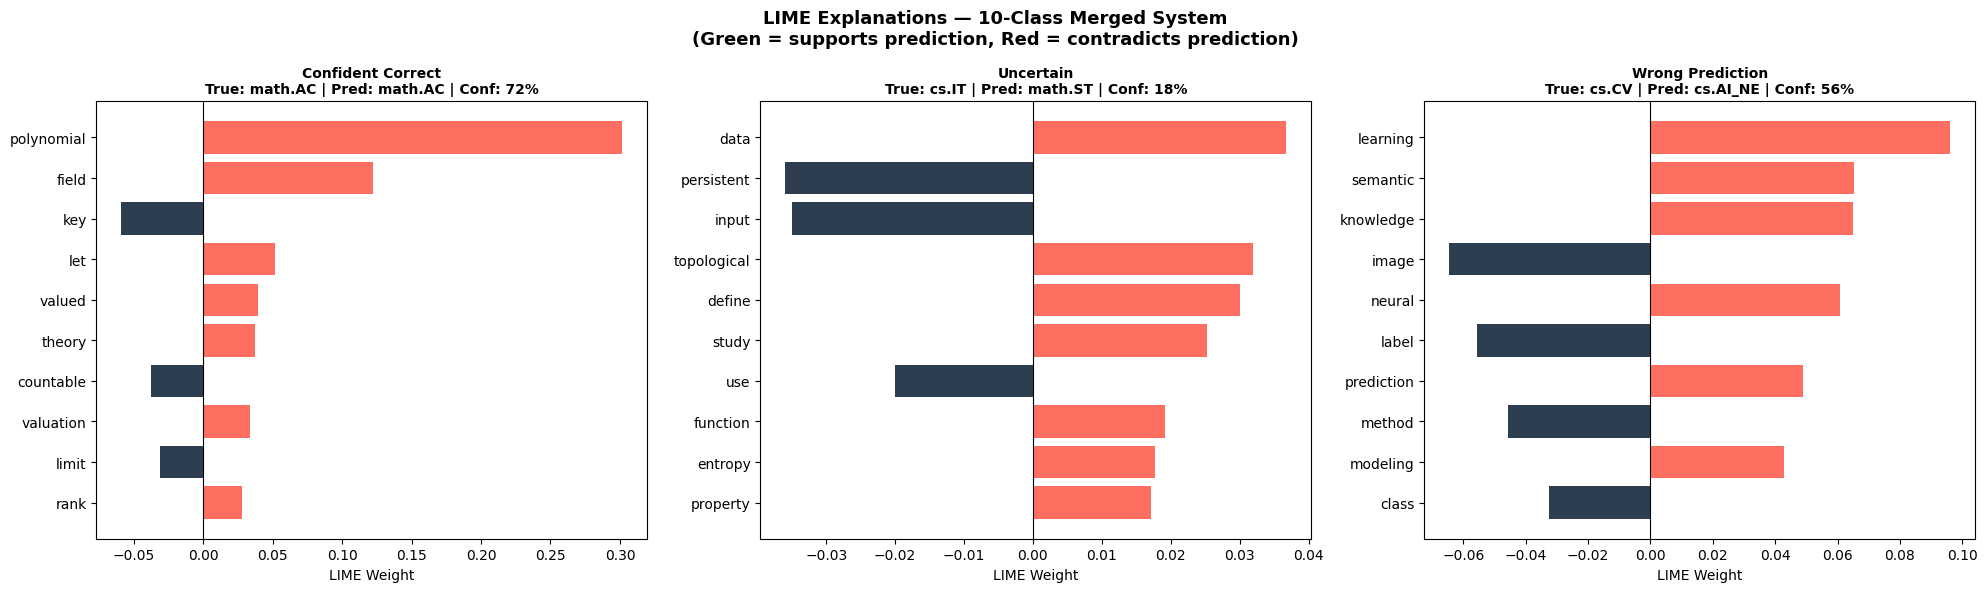

✅ LIME explanations saved as lime_10class.png


In [44]:
# ==========================================
# GENERATE AND PLOT LIME EXPLANATIONS
# 10-CLASS SYSTEM
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (case_name, idx) in zip(axes, samples_to_explain.items()):
    text      = X_test_mb_list[idx]
    true_lab  = le_mb.inverse_transform([y_test_mb_enc[idx]])[0]
    pred_lab  = le_mb.inverse_transform([preds_mb_all[idx]])[0]
    conf      = proba_mb_all[idx].max()

    # Generate LIME explanation
    exp = explainer_mb.explain_instance(
        text,
        predict_proba_mb,
        num_features=10,
        num_samples=500,
        top_labels=1
    )

    # Get top predicted label
    top_label = exp.available_labels()[0]
    words_weights = exp.as_list(label=top_label)

    # Sort by absolute weight
    words_weights.sort(key=lambda x: abs(x[1]), reverse=True)
    words  = [w[0] for w in words_weights[:10]]
    weights = [w[1] for w in words_weights[:10]]
    colors  = ['#FF6F61' if w > 0 else '#2C3E50' for w in weights]

    axes[list(samples_to_explain.keys()).index(case_name)].barh(
        words[::-1], weights[::-1], color=colors[::-1]
    )
    axes[list(samples_to_explain.keys()).index(case_name)].set_title(
        f'{case_name}\nTrue: {true_lab} | Pred: {pred_lab} | Conf: {conf:.0%}',
        fontsize=10, fontweight='bold'
    )
    axes[list(samples_to_explain.keys()).index(case_name)].axvline(x=0, color='black', linewidth=0.8)
    axes[list(samples_to_explain.keys()).index(case_name)].set_xlabel('LIME Weight')

plt.suptitle('LIME Explanations — 10-Class Merged System\n(Green = supports prediction, Red = contradicts prediction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_10class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME explanations saved as lime_10class.png")

In [45]:
# ==========================================
# LIME FOR 11-CLASS HIERARCHICAL SYSTEM
# ==========================================

# For hierarchical we need a wrapper that routes through both stages
def predict_proba_hierarchical(texts):
    results = np.zeros((len(texts), 11))  # 11 original classes
    all_classes = sorted(le.classes_)

    for i, text in enumerate(texts):
        domain = lr_stage1.predict(tfidf_h.transform([text]))[0]

        if domain == 'math':
            probs  = lr_stage2_math.predict_proba(tfidf_math.transform([text]))[0]
            labels = le_math.classes_
        else:
            probs  = grid_cs.best_estimator_.predict_proba([text])[0]
            labels = le_cs.classes_

        for label, prob in zip(labels, probs):
            idx = all_classes.index(label)
            results[i][idx] = prob

    return results

explainer_hier = LimeTextExplainer(
    class_names=sorted(le.classes_),
    random_state=42
)

# Pick samples from hierarchical test set
samples_hier = {
    'Confident Correct': None,
    'Uncertain':         None,
    'Wrong Prediction':  None
}

for i in range(len(X_test_list)):
    text       = X_test_list[i]
    true_label = y_test_list[i]
    top3_labels, top3_scores = all_final_probs[i]
    pred_label = top3_labels[0]
    top1_score = top3_scores[0]
    is_correct = pred_label == true_label

    if samples_hier['Confident Correct'] is None and is_correct and top1_score > 0.7:
        samples_hier['Confident Correct'] = i
    if samples_hier['Uncertain'] is None and top1_score < 0.35:
        samples_hier['Uncertain'] = i
    if samples_hier['Wrong Prediction'] is None and not is_correct and top1_score > 0.5:
        samples_hier['Wrong Prediction'] = i
    if all(v is not None for v in samples_hier.values()):
        break

print("Selected hierarchical samples:")
for case, idx in samples_hier.items():
    true  = y_test_list[idx]
    pred  = all_final_probs[idx][0][0]
    score = all_final_probs[idx][1][0]
    print(f"  {case}: idx={idx}, True={true}, Pred={pred}, Conf={score:.2f}")

Selected hierarchical samples:
  Confident Correct: idx=0, True=cs.PL, Pred=cs.PL, Conf=0.85
  Uncertain: idx=2, True=cs.IT, Pred=cs.IT, Conf=0.32
  Wrong Prediction: idx=63, True=math.ST, Pred=cs.IT, Conf=0.72


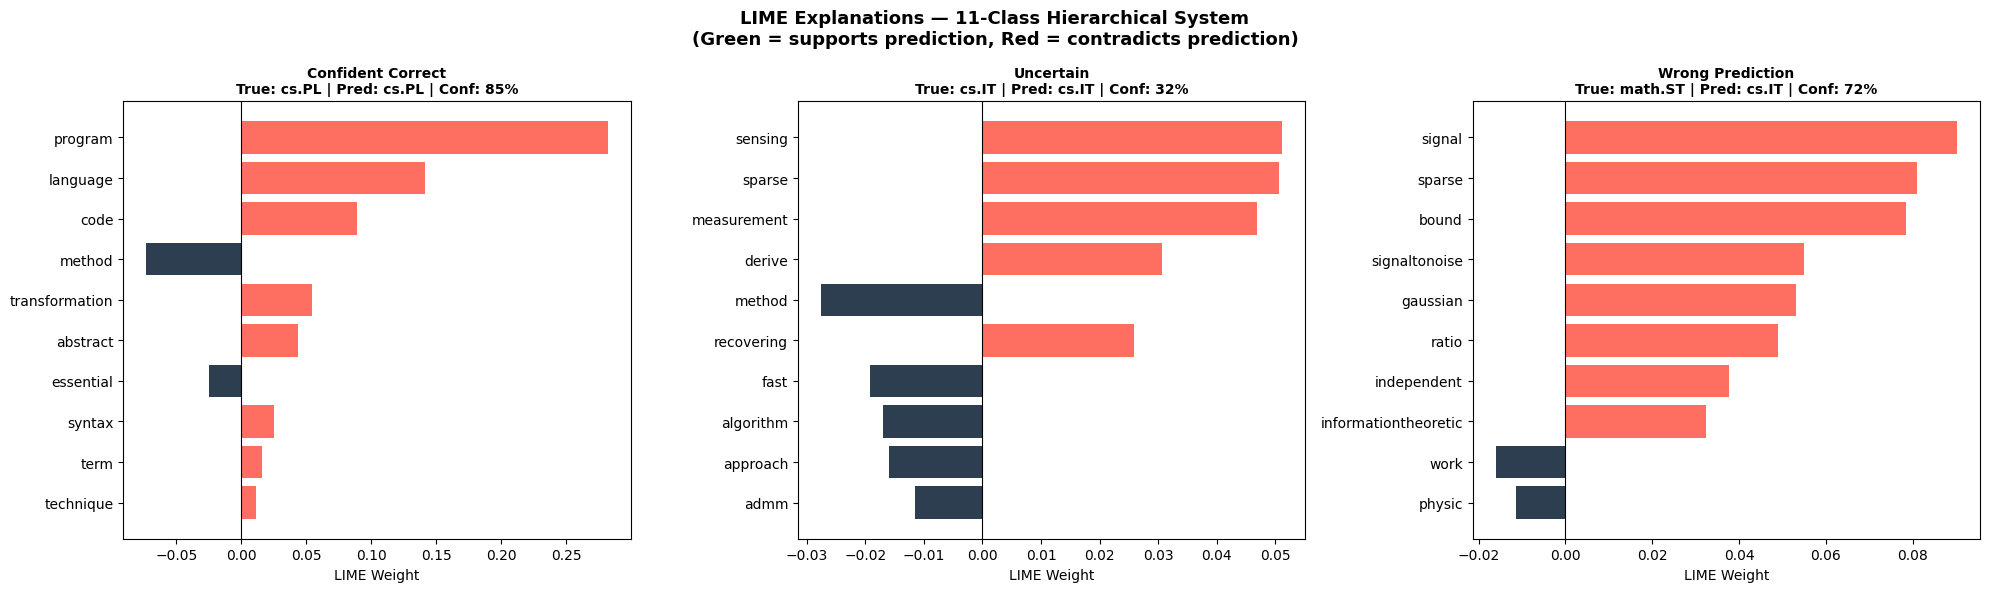

✅ LIME explanations saved as lime_hierarchical.png


In [46]:
# ==========================================
# PLOT LIME — HIERARCHICAL SYSTEM
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax_idx, (case_name, idx) in enumerate(samples_hier.items()):
    text      = X_test_list[idx]
    true_lab  = y_test_list[idx]
    pred_lab  = all_final_probs[idx][0][0]
    conf      = all_final_probs[idx][1][0]

    exp = explainer_hier.explain_instance(
        text,
        predict_proba_hierarchical,
        num_features=10,
        num_samples=500,
        top_labels=1
    )

    top_label     = exp.available_labels()[0]
    words_weights = exp.as_list(label=top_label)
    words_weights.sort(key=lambda x: abs(x[1]), reverse=True)
    words   = [w[0] for w in words_weights[:10]]
    weights = [w[1] for w in words_weights[:10]]
    colors  = ['#FF6F61' if w > 0 else '#2C3E50' for w in weights]

    axes[ax_idx].barh(words[::-1], weights[::-1], color=colors[::-1])
    axes[ax_idx].set_title(
        f'{case_name}\nTrue: {true_lab} | Pred: {pred_lab} | Conf: {conf:.0%}',
        fontsize=10, fontweight='bold'
    )
    axes[ax_idx].axvline(x=0, color='black', linewidth=0.8)
    axes[ax_idx].set_xlabel('LIME Weight')

plt.suptitle('LIME Explanations — 11-Class Hierarchical System\n(Green = supports prediction, Red = contradicts prediction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME explanations saved as lime_hierarchical.png")

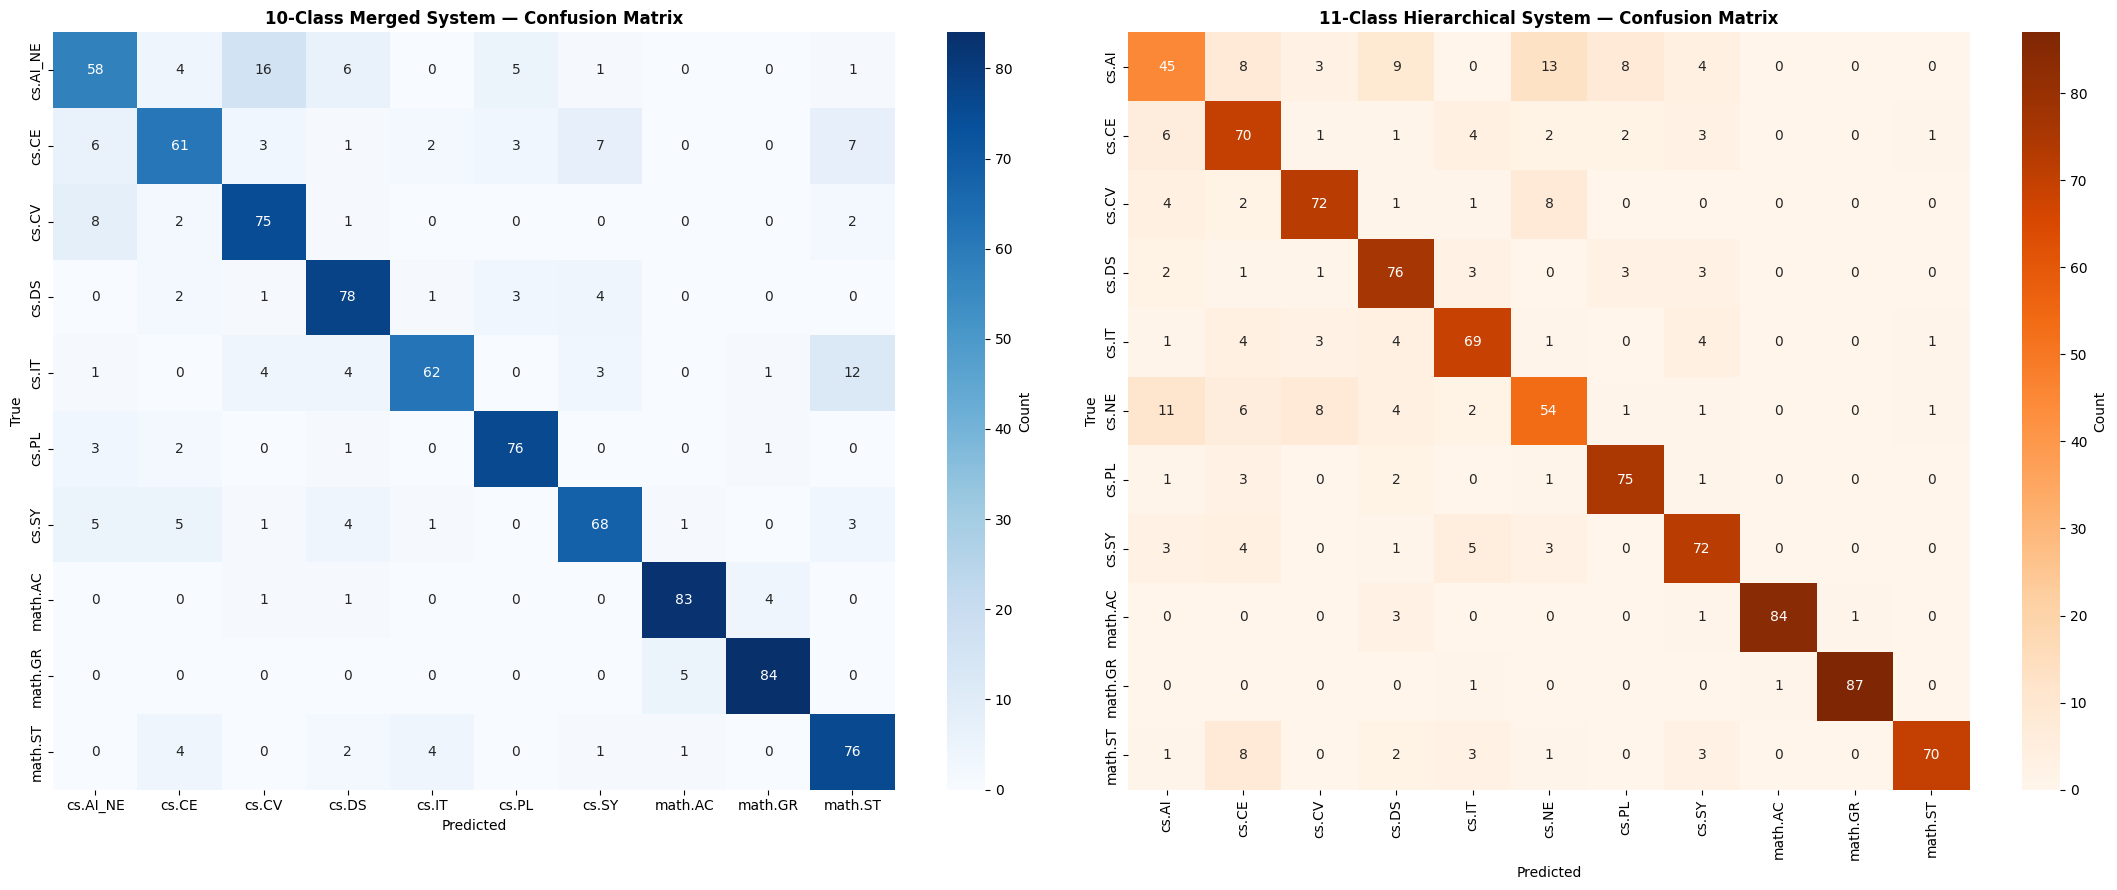

✅ Saved confusion_matrices.png


In [47]:
# ==========================================
# CONFUSION MATRICES — BOTH SYSTEMS
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- 10-Class Merged ----
cm_mb = confusion_matrix(y_test_mb_enc, preds_mb_all, labels=range(len(le_mb.classes_)))
cm_mb_df = pd.DataFrame(cm_mb, index=le_mb.classes_, columns=le_mb.classes_)

# ---- 11-Class Hierarchical ----
all_labels_sorted = sorted(le.classes_)
cm_hier = confusion_matrix(y_test_list, final_preds, labels=all_labels_sorted)
cm_hier_df = pd.DataFrame(cm_hier, index=all_labels_sorted, columns=all_labels_sorted)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm_mb_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('10-Class Merged System — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_hier_df, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('11-Class Hierarchical System — Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved confusion_matrices.png")

In [48]:
print(X_test_mb_list[0])

paper study property persistent entropy shannon entropy persistent barcodes prove stability small perturbation given input data concept define two summary function show use detect topological feature


**FINAL PREDICT FUNCTION**

In [49]:
# ==========================================
# CELL 1: PREPROCESSING SETUP (must run first, exact match to training)
# ==========================================

import re
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

CUSTOM_PHRASE_STOP = [
    'et al', 'paper presents', 'paper propose', 'propose novel',
    'proposed method', 'experimental results', 'simulation results',
    'large scale', 'real world', 'state art', 'end end',
    'key words', 'subject classifications', 'subject descriptors',
    'paper proposes', 'et al.', 'pp qfix'
]

def preprocess(text):
    text = str(text).lower()
    for phrase in CUSTOM_PHRASE_STOP:
        text = text.replace(phrase, '')
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\[a-z]+\{.*?\}', '', text)
    text = re.sub(r'\\[a-z]+', '', text)
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\(\d{4}\)', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("✅ preprocess() restored — vocabulary-consistent with training.")


# ==========================================
# CELL 1B: FINAL PREDICTION FUNCTION — 10-CLASS MERGED SYSTEM
# ==========================================

def predict_category(text, top_k=3, already_cleaned=False):
    """
    Predicts top-k arXiv categories for an abstract.

    already_cleaned=True  -> text has already been through preprocess()
                              (e.g. items pulled from X_test_mb_list)
    already_cleaned=False -> text is raw, unprocessed abstract text
                              (default; use this for new/demo inputs)
    """
    cleaned = text if already_cleaned else preprocess(text)
    probs = grid_mb.best_estimator_.predict_proba([cleaned])[0]
    labels = le_mb.classes_

    top_idx = np.argsort(probs)[::-1][:top_k]
    results = [(labels[i], float(probs[i])) for i in top_idx]

    print(f"Input (first 100 chars): {text[:100]}...")
    if not already_cleaned:
        print(f"Cleaned  (first 100 chars): {cleaned[:100]}...")
    print(f"\nTop-{top_k} Predictions:")
    for rank, (label, score) in enumerate(results, 1):
        bar = '█' * int(score * 40)
        print(f"  {rank}. {label:<12} {score*100:5.1f}%  {bar}")

    return results


# ---- Sanity check: test-set items are ALREADY cleaned ----
print("="*60)
print("SANITY CHECK — held-out test examples (pre-cleaned)")
print("="*60)
for idx in [0, 50, 100]:
    true_label = y_test_mb.iloc[idx] if hasattr(y_test_mb, 'iloc') else y_test_mb[idx]
    print(f"\n--- Test doc #{idx} (True label: {true_label}) ---")
    predict_category(X_test_mb_list[idx], already_cleaned=True)

# ---- Real-world demo: RAW abstract with LaTeX, citations, filler phrases ----
print("\n" + "="*60)
print("REAL-WORLD DEMO — raw, unseen abstract")
print("="*60)
raw_example = """
In this paper, we propose a novel method for adversarial robustness in
deep neural networks for image classification. Recent work [12] has shown
that small perturbations $\\epsilon$ to input images can cause
misclassification (2019). Experimental results on CIFAR-10 and ImageNet
demonstrate the effectiveness of our approach compared to state of the art
baselines.
"""
predict_category(raw_example, already_cleaned=False)

✅ preprocess() restored — vocabulary-consistent with training.
SANITY CHECK — held-out test examples (pre-cleaned)

--- Test doc #0 (True label: cs.IT) ---
Input (first 100 chars): paper study property persistent entropy shannon entropy persistent barcodes prove stability small pe...

Top-3 Predictions:
  1. math.ST       18.4%  ███████
  2. cs.PL         12.3%  ████
  3. cs.IT         12.3%  ████

--- Test doc #50 (True label: math.ST) ---
Input (first 100 chars): find asymptotic formula error probability twofold pearson goodnessoffit test function two critical l...

Top-3 Predictions:
  1. math.ST       50.3%  ████████████████████
  2. cs.IT         15.5%  ██████
  3. cs.AI_NE       5.4%  ██

--- Test doc #100 (True label: cs.PL) ---
Input (first 100 chars): give new proof ptime completeness linear lambda calculus originally given mairson proof us essential...

Top-3 Predictions:
  1. cs.PL         78.3%  ███████████████████████████████
  2. cs.CE          3.7%  █
  3. cs.AI_NE      

[('cs.CV', 0.886400002274552),
 ('cs.AI_NE', 0.08927516591441821),
 ('cs.SY', 0.009270527718833962)]

**SAVE MODEL**

In [50]:
# ==========================================
# CELL 2: MODEL PERSISTENCE — SAVE FINAL PIPELINE
# ==========================================

import joblib
import os

os.makedirs('final_model', exist_ok=True)

# Save the full fitted pipeline (TF-IDF + LogReg)
joblib.dump(grid_mb.best_estimator_, 'final_model/arxiv_classifier_pipeline.joblib')

# Save the label encoder (needed to decode predictions later)
joblib.dump(le_mb, 'final_model/label_encoder.joblib')

# Save the preprocessing dependencies too, so the model is fully portable
import pickle
with open('final_model/custom_phrase_stop.pkl', 'wb') as f:
    pickle.dump(CUSTOM_PHRASE_STOP, f)

print("✅ Saved:")
print("   final_model/arxiv_classifier_pipeline.joblib")
print("   final_model/label_encoder.joblib")
print("   final_model/custom_phrase_stop.pkl")

# ---- Reload test — proves the saved artifact works standalone ----
loaded_pipeline = joblib.load('final_model/arxiv_classifier_pipeline.joblib')
loaded_le = joblib.load('final_model/label_encoder.joblib')

test_text = X_test_mb_list[100]  # already-cleaned cs.PL example
reloaded_pred = loaded_pipeline.predict([test_text])[0]
reloaded_label = loaded_le.inverse_transform([reloaded_pred])[0]

print(f"\nReload test — predicted class: {reloaded_label}")
print("✅ Model reloads and predicts correctly from disk." if reloaded_label == 'cs.PL'
      else "⚠️ Mismatch — investigate before proceeding.")

# ---- File size check (useful for report / deployment notes) ----
for fname in os.listdir('final_model'):
    path = os.path.join('final_model', fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"   {fname}: {size_kb:.1f} KB")

✅ Saved:
   final_model/arxiv_classifier_pipeline.joblib
   final_model/label_encoder.joblib
   final_model/custom_phrase_stop.pkl

Reload test — predicted class: cs.PL
✅ Model reloads and predicts correctly from disk.
   label_encoder.joblib: 0.5 KB
   arxiv_classifier_pipeline.joblib: 1154.9 KB
   custom_phrase_stop.pkl: 0.3 KB


TOP 15 WORDS PER CLASS (by Logistic Regression coefficient)

cs.AI_NE:
  neural, learning, evolutionary, genetic, language, reinforcement, deep, network, training, artificial

cs.CE:
  simulation, computational, equation, stock, element, material, market, dna, tree, model

cs.CV:
  image, segmentation, camera, video, feature, object, method, face, stateoftheart, map

cs.DS:
  algorithm, graph, time, query, vertex, problem, log, approximation, number, edge

cs.IT:
  channel, code, communication, wireless, signal, capacity, information, decoding, scheme, coding

cs.PL:
  program, language, programming, implementation, execution, semantics, type, calculus, code, compiler

cs.SY:
  control, controller, stability, state, linear, vehicle, dynamic, grid, approach, measurement

math.AC:
  ideal, ring, algebra, polynomial, module, commutative, algebraic, cohenmacaulay, field, conjecture

math.GR:
  group, subgroup, finite, prove, content, abelian, growth, representation, hyperbolic, action

mat

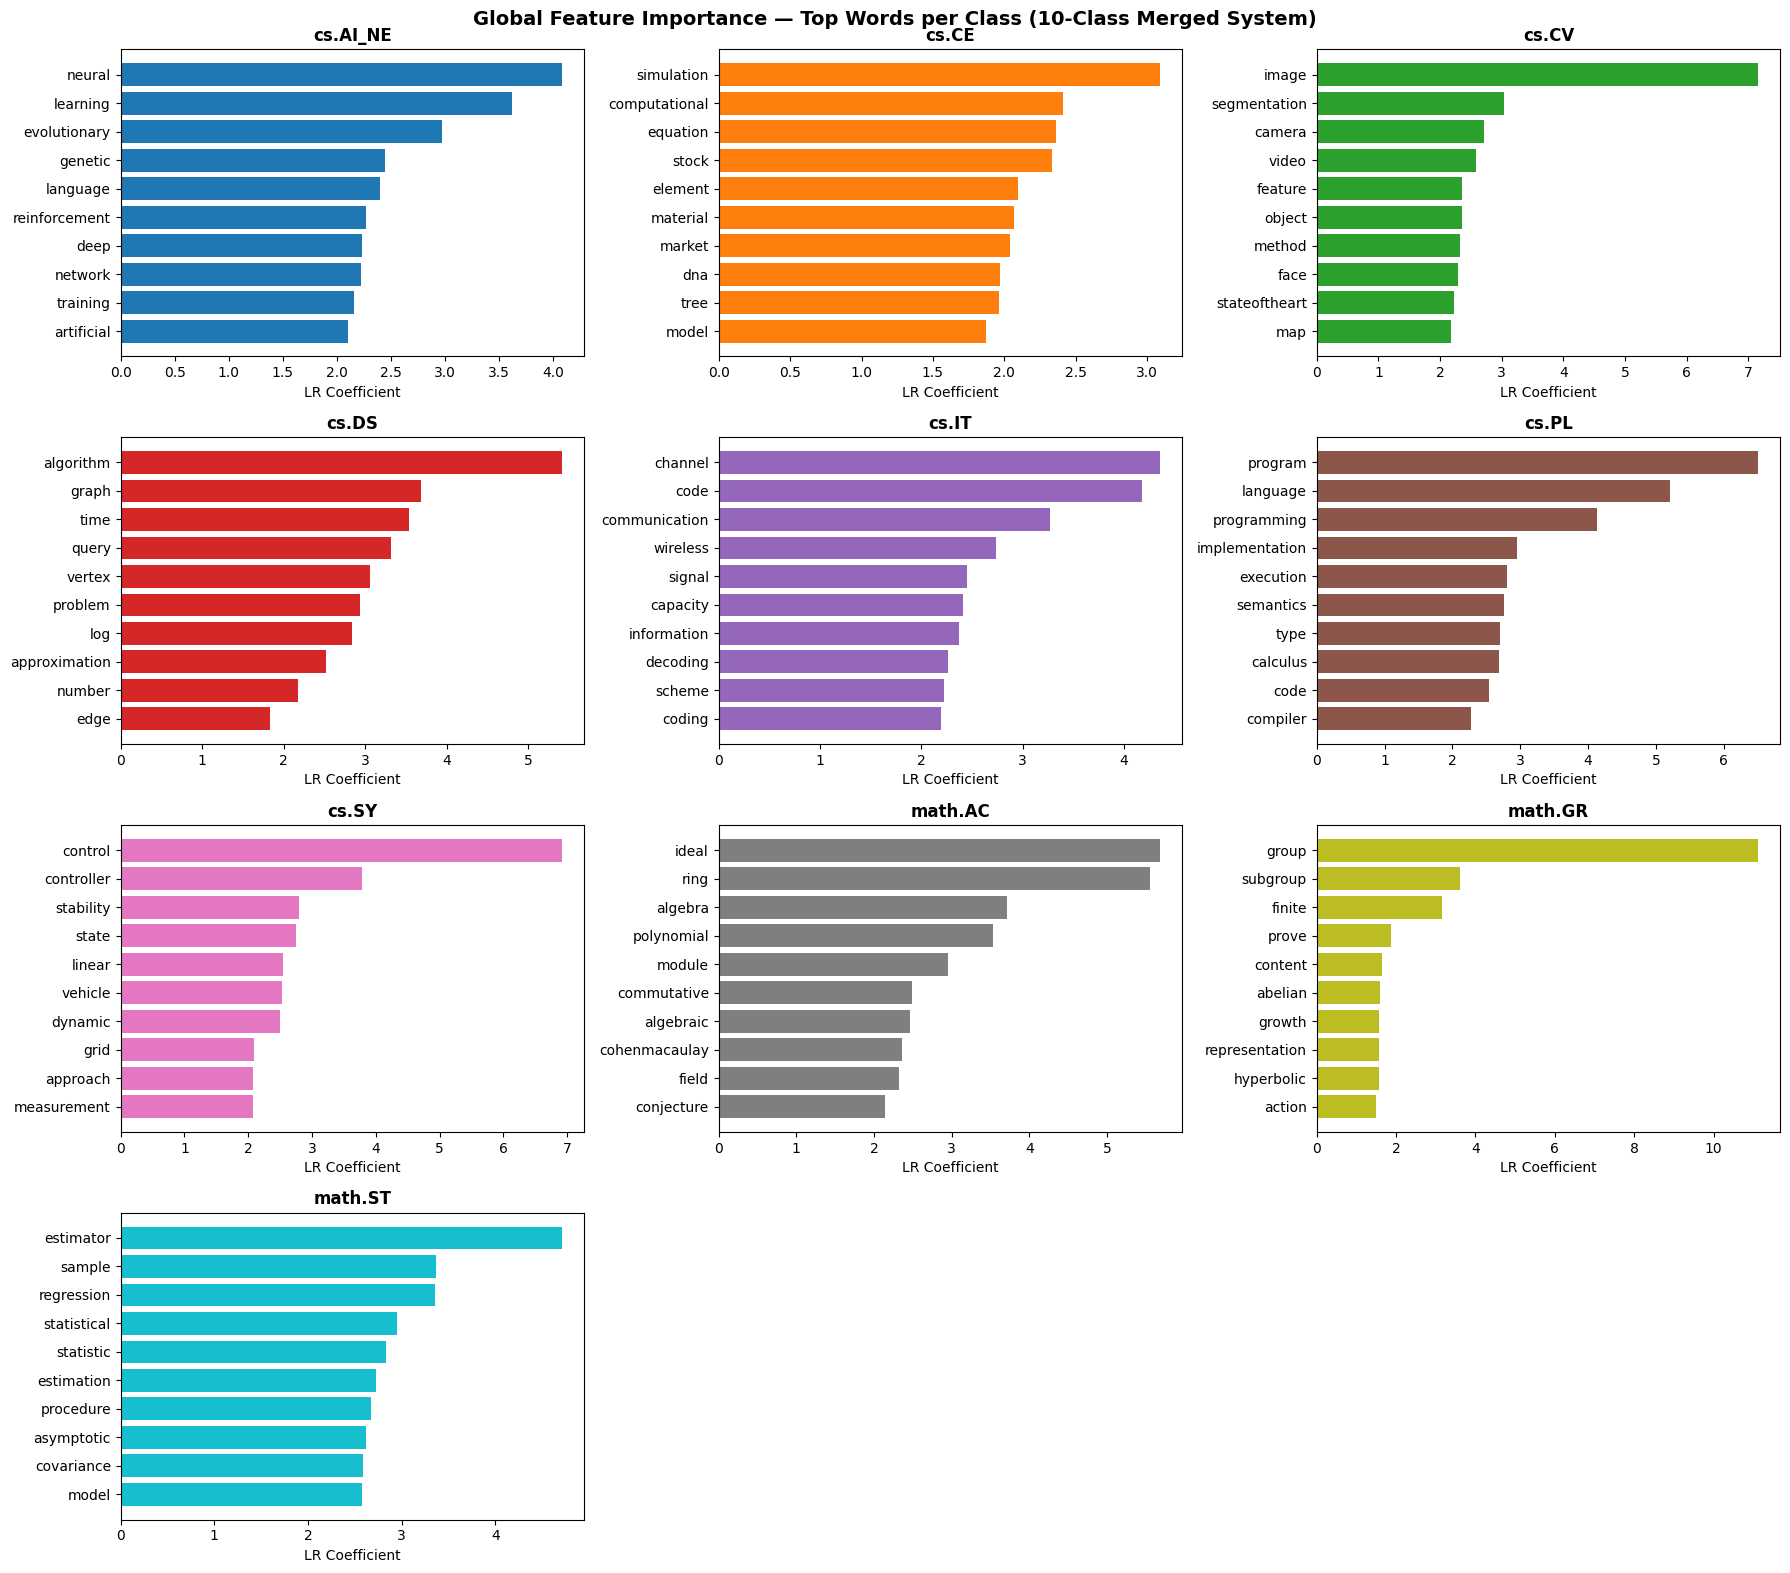


✅ Saved global_feature_importance.png


In [51]:
# ==========================================
# CELL 3: GLOBAL FEATURE IMPORTANCE — PER CLASS (color-coded)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tfidf_final = grid_mb.best_estimator_.named_steps['tfidf']
lr_final     = grid_mb.best_estimator_.named_steps['lr']
feature_names = np.array(tfidf_final.get_feature_names_out())

top_n = 15
importance_table = {}

for class_idx, class_name in enumerate(le_mb.classes_):
    coefs = lr_final.coef_[class_idx]
    top_idx = np.argsort(coefs)[::-1][:top_n]
    top_words = feature_names[top_idx]
    top_scores = coefs[top_idx]
    importance_table[class_name] = list(zip(top_words, top_scores))

print("="*70)
print(f"TOP {top_n} WORDS PER CLASS (by Logistic Regression coefficient)")
print("="*70)
for class_name, words in importance_table.items():
    word_str = ", ".join([f"{w}" for w, s in words[:10]])
    print(f"\n{class_name}:")
    print(f"  {word_str}")

# ---- Distinct color per class, same palette style as your EDA ----
palette = plt.cm.tab10.colors + plt.cm.Set2.colors  # enough distinct colors for 10+ classes
n_classes = len(le_mb.classes_)
n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, (class_name, words) in enumerate(importance_table.items()):
    top_words_plot = words[:10]
    labels_p = [w for w, s in top_words_plot][::-1]
    scores_p = [s for w, s in top_words_plot][::-1]

    axes[i].barh(labels_p, scores_p, color=palette[i % len(palette)])
    axes[i].set_title(class_name, fontweight='bold')
    axes[i].set_xlabel('LR Coefficient')

for j in range(len(importance_table), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Global Feature Importance — Top Words per Class (10-Class Merged System)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('global_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved global_feature_importance.png")

Complete Experiment Results:
                                 Model  Classes  Macro F1  Accuracy
LR + TF-IDF 10k C=2 (Final — 10 class)       10     0.817     0.818
               Hierarchical Classifier       11     0.799     0.799
         SciBERT Fine-tuned (8 epochs)       11     0.798     0.787
                     Class-Weighted LR       11     0.781     0.782
                       Ensemble LR+SVM       11     0.781     0.782
        Logistic Regression (baseline)       11     0.781     0.782
                            Linear SVM       11     0.776     0.779
                    LR + TF-IDF Bigram       11     0.775     0.776
               LR + TF-IDF 15k (tuned)       11     0.773     0.774
                            SMOTE + LR       11     0.771     0.769
               Multinomial Naive Bayes       11     0.758     0.761
                 SBERT + Random Forest       11     0.736     0.738
                         Random Forest       11     0.709     0.716
                   

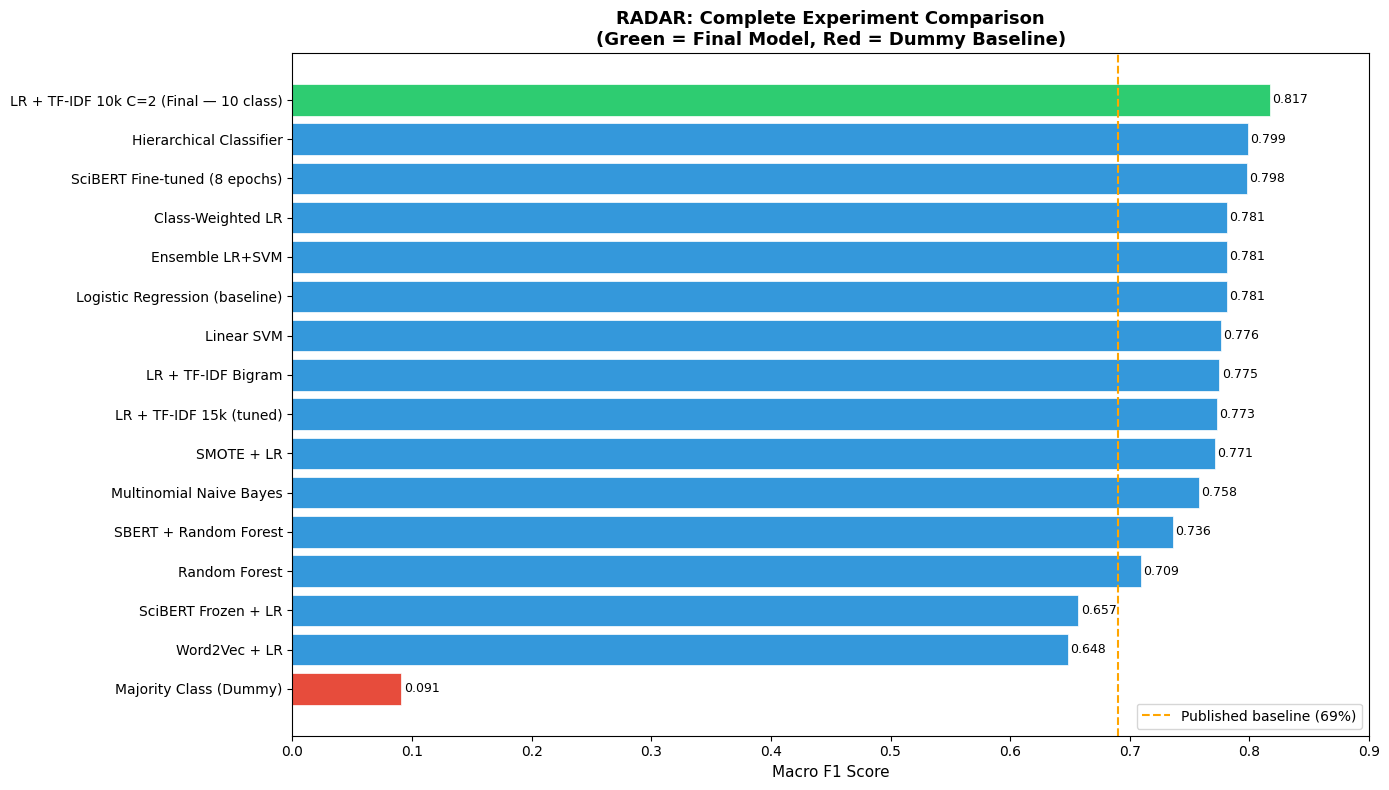

In [53]:
# ==========================================
# CELL 4: REAL BASELINE COMPARISON TABLE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_data = {
    'Model': [
        'Majority Class (Dummy)',
        'Multinomial Naive Bayes',
        'Random Forest',
        'Linear SVM',
        'Logistic Regression (baseline)',
        'LR + TF-IDF Bigram',
        'LR + TF-IDF 15k (tuned)',
        'Class-Weighted LR',
        'Ensemble LR+SVM',
        'Word2Vec + LR',
        'SMOTE + LR',
        'SBERT + Random Forest',
        'SciBERT Frozen + LR',
        'SciBERT Fine-tuned (8 epochs)',
        'Hierarchical Classifier',
        'LR + TF-IDF 10k C=2 (Final — 10 class)'
    ],
    'Representation': [
        'None',
        'TF-IDF 5k',
        'TF-IDF 5k',
        'TF-IDF 5k',
        'TF-IDF 5k',
        'TF-IDF Bigram 5k',
        'TF-IDF 15k',
        'TF-IDF 5k',
        'TF-IDF 10k',
        'Word2Vec 300d',
        'TF-IDF 10k',
        'SBERT 384d',
        'SciBERT 768d',
        'SciBERT 768d',
        'TF-IDF (staged)',
        'TF-IDF 10k'
    ],
    'Classes': [
        11, 11, 11, 11, 11, 11, 11, 11, 11,
        11, 11, 11, 11, 11, 11, 10
    ],
    'Macro F1': [
        0.091, 0.758, 0.709, 0.776, 0.781,
        0.775, 0.773, 0.781, 0.781,
        0.648, 0.771, 0.736, 0.657,
        0.798, 0.799, 0.817
    ],
    'Accuracy': [
        0.091, 0.761, 0.716, 0.779, 0.782,
        0.776, 0.774, 0.782, 0.782,
        0.648, 0.769, 0.738, 0.657,
        0.787, 0.799, 0.818
    ]
}

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print("Complete Experiment Results:")
print(results_df[['Model', 'Classes', 'Macro F1', 'Accuracy']].to_string(index=False))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2ecc71' if i == 0 else
          '#e74c3c' if i == len(results_df)-1 else
          '#3498db'
          for i in range(len(results_df))]

bars = ax.barh(
    results_df['Model'],
    results_df['Macro F1'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, results_df['Macro F1']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(x=0.69, color='orange', linestyle='--',
           linewidth=1.5, label='Published baseline (69%)')
ax.set_xlabel('Macro F1 Score', fontsize=11)
ax.set_title('RADAR: Complete Experiment Comparison\n(Green = Final Model, Red = Dummy Baseline)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.90)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Targeted cases found: {'cs.CV -> misclassified as cs.AI_NE': 22, 'cs.AI_NE -> misclassified as cs.CV': 86}


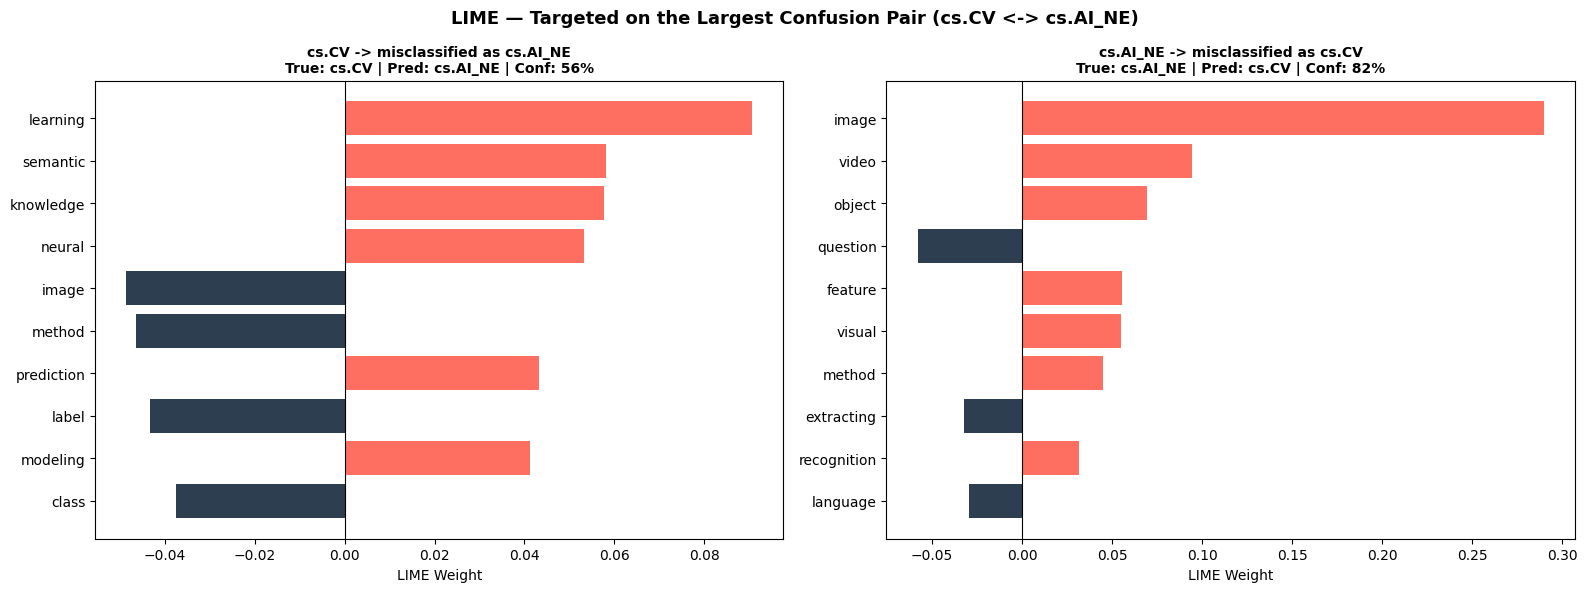

✅ Saved lime_targeted_cv_ai_ne.png


In [56]:
# ==========================================
# UNIQUE LIME — TARGETED ON THE PROBLEM PAIR (cs.AI_NE vs cs.CV)
# ==========================================

from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import numpy as np

explainer_mb = LimeTextExplainer(class_names=le_mb.classes_, random_state=42)

def predict_proba_mb(texts):
    return grid_mb.best_estimator_.predict_proba(texts)

preds_mb_all = grid_mb.best_estimator_.predict(X_test_mb_list)
proba_mb_all = grid_mb.best_estimator_.predict_proba(X_test_mb_list)

# Find a genuine CV-doc-misclassified-as-AI_NE case, and vice versa
cv_idx = le_mb.transform(['cs.CV'])[0]
ai_ne_idx = le_mb.transform(['cs.AI_NE'])[0]

cv_confused_as_ai = None
ai_confused_as_cv = None

for i in range(len(X_test_mb_list)):
    true_c = y_test_mb_enc[i]
    pred_c = preds_mb_all[i]
    if true_c == cv_idx and pred_c == ai_ne_idx and cv_confused_as_ai is None:
        cv_confused_as_ai = i
    if true_c == ai_ne_idx and pred_c == cv_idx and ai_confused_as_cv is None:
        ai_confused_as_cv = i
    if cv_confused_as_ai is not None and ai_confused_as_cv is not None:
        break

targeted_cases = {
    'cs.CV -> misclassified as cs.AI_NE': cv_confused_as_ai,
    'cs.AI_NE -> misclassified as cs.CV': ai_confused_as_cv
}
print("Targeted cases found:", targeted_cases)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (case_name, idx) in enumerate(targeted_cases.items()):
    if idx is None:
        axes[ax_idx].set_title(f"{case_name}\n(no matching case found in test set)")
        continue

    text = X_test_mb_list[idx]
    true_lab = le_mb.inverse_transform([y_test_mb_enc[idx]])[0]
    pred_lab = le_mb.inverse_transform([preds_mb_all[idx]])[0]
    conf = proba_mb_all[idx].max()

    exp = explainer_mb.explain_instance(text, predict_proba_mb, num_features=10,
                                         num_samples=500, top_labels=1)
    top_label = exp.available_labels()[0]
    words_weights = exp.as_list(label=top_label)
    words_weights.sort(key=lambda x: abs(x[1]), reverse=True)
    words = [w[0] for w in words_weights[:10]]
    weights = [w[1] for w in words_weights[:10]]
    colors  = ['#FF6F61' if w > 0 else '#2C3E50' for w in weights]

    axes[ax_idx].barh(words[::-1], weights[::-1], color=colors[::-1])
    axes[ax_idx].set_title(f'{case_name}\nTrue: {true_lab} | Pred: {pred_lab} | Conf: {conf:.0%}',
                            fontsize=10, fontweight='bold')
    axes[ax_idx].axvline(x=0, color='black', linewidth=0.8)
    axes[ax_idx].set_xlabel('LIME Weight')

plt.suptitle('LIME — Targeted on the Largest Confusion Pair (cs.CV <-> cs.AI_NE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_targeted_cv_ai_ne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved lime_targeted_cv_ai_ne.png")

In [55]:
# ==========================================
# QUANTITATIVE LIME VALIDATION
# "Does LIME's top word match the class's known global top-15 features?"
# ==========================================

import random
random.seed(42)

# Reuse importance_table from Cell 3 (global top-15 words per class)
sample_size = 40
sample_indices = random.sample(range(len(X_test_mb_list)), sample_size)

match_count = 0
results_log = []

for idx in sample_indices:
    text = X_test_mb_list[idx]
    pred_class_idx = preds_mb_all[idx]
    pred_class_name = le_mb.inverse_transform([pred_class_idx])[0]

    exp = explainer_mb.explain_instance(text, predict_proba_mb, num_features=5,
                                         num_samples=300, top_labels=1)
    top_label = exp.available_labels()[0]
    lime_top_word = exp.as_list(label=top_label)[0][0]  # highest |weight| word

    global_top_words = [w for w, s in importance_table[pred_class_name][:15]]
    is_match = lime_top_word in global_top_words
    match_count += is_match

    results_log.append({
        'idx': idx, 'predicted_class': pred_class_name,
        'lime_top_word': lime_top_word, 'matches_global_top15': is_match
    })

match_rate = match_count / sample_size * 100
print(f"LIME-to-global-feature agreement: {match_count}/{sample_size} = {match_rate:.1f}%")
print("\nSample of results:")
results_df = pd.DataFrame(results_log)
print(results_df.head(15).to_string(index=False))

LIME-to-global-feature agreement: 31/40 = 77.5%

Sample of results:
 idx predicted_class lime_top_word  matches_global_top15
 654         math.AC        module                  True
 114           cs.CV        metric                 False
  25           cs.CE        genome                 False
 759           cs.PL      language                  True
 281        cs.AI_NE      training                  True
 250        cs.AI_NE      learning                  True
 228         math.GR         group                  True
 142           cs.SY      feedback                  True
 754           cs.CE      material                  True
 104           cs.CE  phylogenetic                 False
 692        cs.AI_NE        neural                  True
 758         math.GR         group                  True
 558        cs.AI_NE        neural                  True
  89           cs.PL       program                  True
 604           cs.PL       program                  True
